<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/extra/extra 02 - Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Clustering

Every model of the course so far learned from **labelled** examples: a price, a class, a next word. Most data come without labels. An insurer has millions of policyholders and no column that says which "type" each one is; a claims department has thousands of free-text descriptions and no topic for them; a photo has 100,000 colours and we want 16. **Clustering** finds groups in unlabelled data: points in the same group are similar, points in different groups are not.

There is no single right answer. A cluster can be a compact ball, a long connected chain or a dense region surrounded by empty space, and each definition gives a different algorithm. The result also depends on the distance we choose and on the units of the features. In this lab we build the main algorithms from scratch (k-means and k-means++, the silhouette, EM for Gaussian mixtures, DBSCAN and spectral clustering), check each one against scikit-learn, see where each one breaks, and learn how to evaluate a clustering with and without labels.

**Contents**

1. Unlabelled data: what a cluster is, and why the units matter
2. k-means from scratch: Lloyd's algorithm
3. Initialisation: local minima and k-means++
4. Choosing $k$: the elbow and the silhouette
5. What k-means assumes; mini-batch k-means; colour quantisation
6. Gaussian mixtures and EM from scratch
7. Hierarchical clustering
8. Density: DBSCAN from scratch and HDBSCAN
9. Spectral clustering from scratch
10. Evaluating a clustering
11. A real dataset: handwritten digits
12. Practice: mixed data, the Gower distance and cluster profiles
13. Summary and exercises

This lab goes with the slides *Extra 2 · Clustering* and uses the same notation. It assumes the machine-learning part of the course (distances, train/validation/test, PCA is recalled where it is used); section 9 reuses the graph Laplacian and the Fiedler vector of *Extra 1 · Graph neural networks*. Everything is NumPy and scikit-learn: it runs on a CPU in about a minute (20 seconds with 4 CPU threads), no GPU needed, and needs no download (all data are generated or bundled with scikit-learn).

**Notation**

| Symbol | Meaning |
|---|---|
| $\mathbf{X} \in \mathbb{R}^{n \times d}$, $\mathbf{x}_i$ | the data: $n$ points (rows) with $d$ features, **no labels** |
| $k$ | number of clusters (or of mixture components) |
| $c_i \in \{1, \dots, k\}$ | cluster of point $i$ (a hard assignment) |
| $C_j$, $n_j = \lvert C_j \rvert$ | the set of points of cluster $j$ and its size |
| $\boldsymbol{\mu}_j$ | centroid of cluster $j$ (k-means) or mean of component $j$ (GMM) |
| $J = \sum_i \lVert \mathbf{x}_i - \boldsymbol{\mu}_{c_i} \rVert^2$ | the k-means objective: within-cluster sum of squares (WCSS, scikit-learn's `inertia_`) |
| $\pi_j$, $\boldsymbol{\Sigma}_j$ | mixing weight and covariance matrix of Gaussian component $j$ |
| $\gamma_{ij}$ | responsibility $P(\text{component } j \mid \mathbf{x}_i)$: a soft assignment, $\sum_j \gamma_{ij} = 1$ |
| $\ell(\boldsymbol{\theta}) = \sum_i \log p(\mathbf{x}_i)$ | log-likelihood of the mixture |
| $a(i)$, $b(i)$, $s(i)$ | silhouette: mean distance to the own cluster, to the nearest other cluster, and $s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$ |
| $\varepsilon$, `min_samples` | DBSCAN: neighbourhood radius, and the number of points (itself included) within $\varepsilon$ that makes a point a core point |
| $\mathbf{A}$, $\mathbf{D}$, $\mathbf{L} = \mathbf{D} - \mathbf{A}$ | similarity graph (weighted adjacency), degree matrix, graph Laplacian (as in Extra 1) |
| ARI, NMI | adjusted Rand index and normalised mutual information: agreement with known labels |

In [1]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import scipy
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.optimize import linear_sum_assignment
from scipy.special import logsumexp
import sklearn
from sklearn.datasets import make_blobs, make_moons, make_circles, load_digits, load_sample_image
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering, DBSCAN, HDBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors, kneighbors_graph
from sklearn.metrics import (silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, normalized_mutual_info_score)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
np.set_printoptions(precision=3, suppress=True)
SEED = 0
np.random.seed(SEED)
device = "cpu"          # NumPy and scikit-learn only: no GPU is needed in this lab
print("device:", device, "| numpy", np.__version__, "| scipy", scipy.__version__, "| scikit-learn", sklearn.__version__)
T_START = time.time()

PALETTE = np.array(plt.cm.tab10.colors)

def label_colors(labels):
    # One tab10 colour per cluster; noise (label -1) in light grey.
    labels = np.asarray(labels)
    c = PALETTE[np.mod(labels, 10)]
    c[labels < 0] = (0.8, 0.8, 0.8)
    return c

def scatter(ax, X, labels=None, title="", s=10, equal=True):
    # Scatter plot coloured by cluster label (grey if no labels); noise points drawn as small crosses.
    if labels is None:
        ax.scatter(X[:, 0], X[:, 1], s=s, c="0.45")
    else:
        labels = np.asarray(labels)
        m = labels >= 0
        ax.scatter(X[m, 0], X[m, 1], s=s, c=label_colors(labels[m]))
        if (~m).any():
            ax.scatter(X[~m, 0], X[~m, 1], s=s + 6, c="0.6", marker="x", linewidths=0.8)
    ax.set_title(title)
    if equal:
        ax.set_aspect("equal", adjustable="datalim")

device: cpu | numpy 2.3.3 | scipy 1.17.1 | scikit-learn 1.8.0


## 1. Unlabelled data: what a cluster is, and why the units matter

In supervised learning each $\mathbf{x}_i$ comes with a $y_i$ and the loss tells us how wrong we are. Here we only have $\mathbf{X}$. A **clustering** assigns each point to one of $k$ groups, $c_i \in \{1, \dots, k\}$ (a *hard* clustering), or gives each point a probability for each group (a *soft* clustering). What counts as a "group" is a modelling choice. Three common definitions:

- **compact**: points are close to a centre (k-means, Gaussian mixtures);
- **connected**: points can be linked by a chain of close neighbours, whatever the shape (single linkage, spectral clustering);
- **dense**: a cluster is a region of high density separated from others by low density, and isolated points are **noise** (DBSCAN, HDBSCAN).

An algorithm is a definition of "cluster" plus a search procedure. We use the six two-dimensional datasets of scikit-learn's famous clustering comparison (500 points each, every feature standardised). The colours below show how each set was generated; the algorithms never see them. We use them only to **evaluate** (section 10).

circles       X (500, 2)   generating groups: [250, 250]   mean [-0. -0.], std [1. 1.]
moons         X (500, 2)   generating groups: [250, 250]   mean [-0. -0.], std [1. 1.]
varied        X (500, 2)   generating groups: [167, 167, 166]   mean [-0.  0.], std [1. 1.]
aniso         X (500, 2)   generating groups: [167, 167, 166]   mean [-0.  0.], std [1. 1.]
blobs         X (500, 2)   generating groups: [167, 167, 166]   mean [-0.  0.], std [1. 1.]
no structure  X (500, 2)   generating groups: none   mean [0. 0.], std [1. 1.]


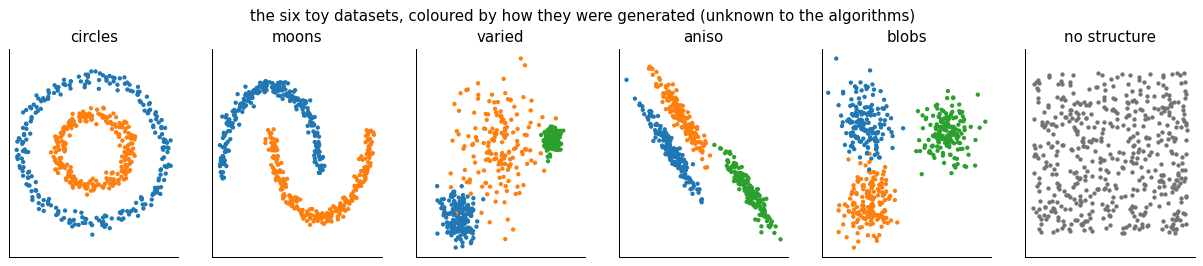

In [2]:
n_toy, seed_toy = 500, 30
X_aniso, y_aniso = make_blobs(n_samples=n_toy, random_state=170)
raw = {
    "circles": make_circles(n_samples=n_toy, factor=0.5, noise=0.05, random_state=seed_toy),
    "moons": make_moons(n_samples=n_toy, noise=0.05, random_state=seed_toy),
    "varied": make_blobs(n_samples=n_toy, cluster_std=[1.0, 2.5, 0.5], random_state=170),
    "aniso": (X_aniso @ np.array([[0.6, -0.6], [-0.4, 0.8]]), y_aniso),    # blobs stretched by a linear map
    "blobs": make_blobs(n_samples=n_toy, random_state=seed_toy),
    "no structure": (np.random.RandomState(seed_toy).rand(n_toy, 2), None),
}
toy = {name: (StandardScaler().fit_transform(X), y) for name, (X, y) in raw.items()}
k_toy = {"circles": 2, "moons": 2, "varied": 3, "aniso": 3, "blobs": 3, "no structure": 3}

for name, (X, y) in toy.items():
    sizes = "none" if y is None else np.bincount(y).tolist()
    print(f"{name:13s} X {X.shape}   generating groups: {sizes}   mean {X.mean(0).round(2)}, std {X.std(0).round(2)}")

fig, axes = plt.subplots(1, 6, figsize=(17, 3.0))
for ax, (name, (X, y)) in zip(axes, toy.items()):
    scatter(ax, X, y, name, s=6)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("the six toy datasets, coloured by how they were generated (unknown to the algorithms)", y=1.03)
plt.show()

**Things to notice.** The *blobs* are compact and round: almost any method finds them. The *aniso* blobs are stretched ellipses, the *varied* blobs have very different spreads, the *moons* and *circles* are connected shapes that no centre describes, and *no structure* is uniform noise: an honest method should not find clusters there. Keep these six in mind; section 10 runs every algorithm on every one of them.

### The distance decides, and so do the units

Most methods compare points through a distance, usually the Euclidean one, $\lVert \mathbf{x} - \mathbf{x}' \rVert = \sqrt{\sum_f (x_f - x'_f)^2}$. The sum adds the squared differences of all features **in their own units**, so a feature measured in large numbers dominates. A small example with policyholders: two groups by age (young drivers around 27, seniors around 60), with an annual premium between 300 and 1,500 € that does not depend on the group. We run k-means with $k = 2$ (section 2) on three versions of the same table.

age (years), premium (€)    ARI with the age groups: -0.000   (1 = finds the two age groups, 0 = unrelated)
age (years), premium (k€)   ARI with the age groups: 1.000   (1 = finds the two age groups, 0 = unrelated)
both standardised           ARI with the age groups: 1.000   (1 = finds the two age groups, 0 = unrelated)

raw euros       : d(a, b) =   42.1   d(a, c) =  300.0   -> the 25-year-old is 'closer' to the 62-year-old
standardised    : d(a, b) =   2.19   d(a, c) =   0.88   -> closer to the 26-year-old   (std of age 16.9 years, of premium 340 €)


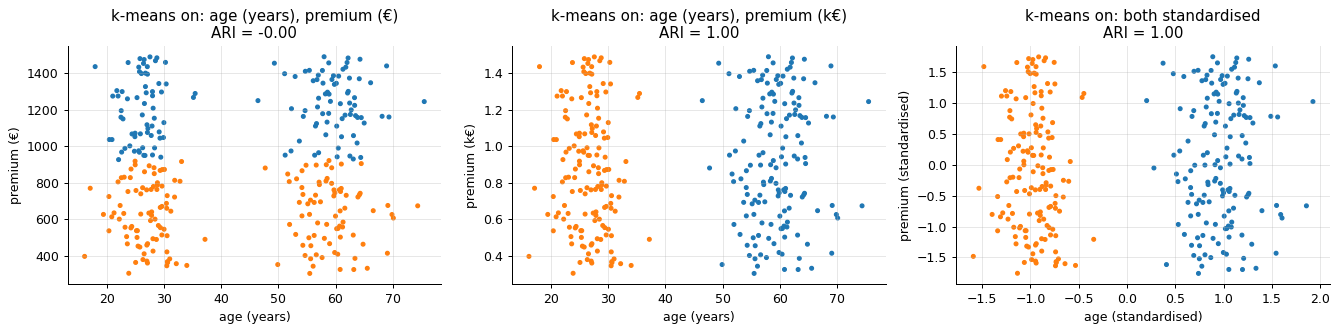

In [3]:
rng = np.random.default_rng(1)
n_young, n_senior = 150, 150
age = np.r_[rng.normal(27, 4, n_young), rng.normal(60, 5, n_senior)]
premium = rng.uniform(300, 1500, n_young + n_senior)            # euros, the same for both groups
group = np.r_[np.zeros(n_young, int), np.ones(n_senior, int)]   # 0 = young, 1 = senior (hidden)
X_pol = np.c_[age, premium]

versions = {"age (years), premium (€)": X_pol,
            "age (years), premium (k€)": np.c_[age, premium / 1000],
            "both standardised": StandardScaler().fit_transform(X_pol)}
labels_pol = {}
for name, Xv in versions.items():
    labels_pol[name] = KMeans(2, n_init=10, random_state=0).fit_predict(Xv)
    print(f"{name:27s} ARI with the age groups: {adjusted_rand_score(group, labels_pol[name]):.3f}"
          "   (1 = finds the two age groups, 0 = unrelated)")

# three policyholders: who is closer to whom?
a, b, c = np.array([25, 800.]), np.array([62, 820.]), np.array([26, 1100.])
sd = X_pol.std(0)
print(f"\nraw euros       : d(a, b) = {np.linalg.norm(a - b):6.1f}   d(a, c) = {np.linalg.norm(a - c):6.1f}"
      "   -> the 25-year-old is 'closer' to the 62-year-old")
print(f"standardised    : d(a, b) = {np.linalg.norm((a - b) / sd):6.2f}   d(a, c) = {np.linalg.norm((a - c) / sd):6.2f}"
      f"   -> closer to the 26-year-old   (std of age {sd[0]:.1f} years, of premium {sd[1]:.0f} €)")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, (name, Xv) in zip(axes, versions.items()):
    ax.scatter(Xv[:, 0], Xv[:, 1], s=9, c=label_colors(labels_pol[name]))
    ax.set_title(f"k-means on: {name}\nARI = {adjusted_rand_score(group, labels_pol[name]):.2f}")
    ax.set_xlabel("age" + (" (standardised)" if "stand" in name else " (years)"))
    ax.set_ylabel("premium" + (" (standardised)" if "stand" in name else " (€)" if "(€)" in name else " (k€)"))
plt.tight_layout(); plt.show()

**What just happened?** The same 300 policyholders give two opposite clusterings. In euros, the premium spans about 1,200 units and the age about 50, so the distance is almost only the premium: k-means cuts the premium axis in two and ignores the age (ARI 0.00). Written in k€, the premium spans 1.2 units and the age dominates: k-means finds the age groups (ARI 1.00). After standardising (each column minus its mean, divided by its standard deviation) both features count equally and the age groups appear (ARI 1.00).

The three policyholders make it concrete: in raw euros the 25-year-old is at distance 42.1 from the 62-year-old and 300.0 from the 26-year-old, so the senior is the "neighbour". Standardised, the distances are 2.19 and 0.88, the other way round.

**Lesson.** A clustering is only as meaningful as its distance. Before clustering: put the features on comparable scales (standardise, or use domain weights), think about which features should matter at all, and remember that changing the units can change the answer completely. Standardising is a default, not a law: it gives a feature of pure noise the same weight as an informative one.

**What clustering is used for.**
- **Segmentation**: groups of customers or policyholders for pricing, marketing or retention.
- **Document topics**: group claim descriptions, complaints or articles by their word vectors.
- **Compression**: replace every colour of an image by the nearest of $k$ representative colours (section 5).
- **Pre-labelling**: label one example per cluster and propagate, or label clusters instead of points.
- **Exploration and anomalies**: points far from every cluster, or flagged as noise by DBSCAN, deserve a look.

## 2. k-means from scratch: Lloyd's algorithm

**The objective.** k-means looks for $k$ centroids $\boldsymbol{\mu}_1, \dots, \boldsymbol{\mu}_k$ and an assignment $c_i$ of every point that minimise the **within-cluster sum of squares**

$$
J(c, \boldsymbol{\mu}) = \sum_{i=1}^{n} \lVert \mathbf{x}_i - \boldsymbol{\mu}_{c_i} \rVert^2 = \sum_{j=1}^{k} \sum_{i \in C_j} \lVert \mathbf{x}_i - \boldsymbol{\mu}_j \rVert^2 .
$$

Finding the global minimum is NP-hard, but two sub-problems are easy.

**Fact 1: for fixed centroids, assign each point to its nearest centroid.** $J$ is a sum of one term per point, and the term of point $i$ depends only on $c_i$, so each term is minimised separately by $c_i = \arg\min_j \lVert \mathbf{x}_i - \boldsymbol{\mu}_j \rVert^2$.

**Fact 2: for fixed assignments, the best centroid is the mean of its cluster.** For one cluster, add and subtract the mean $\bar{\mathbf{x}}_j = \frac{1}{n_j}\sum_{i \in C_j} \mathbf{x}_i$:

$$
\sum_{i \in C_j} \lVert \mathbf{x}_i - \boldsymbol{\mu} \rVert^2 = \sum_{i \in C_j} \lVert \mathbf{x}_i - \bar{\mathbf{x}}_j \rVert^2 + n_j \lVert \bar{\mathbf{x}}_j - \boldsymbol{\mu} \rVert^2 ,
$$

because the cross term $2(\bar{\mathbf{x}}_j - \boldsymbol{\mu})^\top \sum_{i \in C_j} (\mathbf{x}_i - \bar{\mathbf{x}}_j)$ is zero (deviations from a mean sum to zero). The first term does not depend on $\boldsymbol{\mu}$ and the second is minimal, zero, at $\boldsymbol{\mu} = \bar{\mathbf{x}}_j$. $\blacksquare$

**Lloyd's algorithm** alternates the two facts: start from $k$ centroids, then repeat (1) **assign** every point to its nearest centroid, (2) **update** every centroid to the mean of its points, until the assignments stop changing.

**Why it stops.** Each step minimises $J$ over one block of variables with the other block fixed, so neither step can increase $J$. There are at most $k^n$ assignments; as long as the assignment changes, $J$ strictly decreases (we keep the old assignment on ties), so no assignment can come back and the algorithm stops after finitely many steps. It stops at a **fixed point**: every point is nearest to its own centroid and every centroid is the mean of its points. That is a local minimum, not necessarily the global one (section 3).

We first run it by hand on six points, the worked example of the slides.

In [4]:
def assign(X, C):
    # Nearest centroid of every row of X; also returns the n x k matrix of squared distances.
    D2 = ((X[:, None, :] - C[None, :, :]) ** 2).sum(-1)
    return D2.argmin(1), D2

def update(X, labels, C_old):
    # Mean of every cluster (an empty cluster keeps its old centroid).
    return np.array([X[labels == j].mean(0) if np.any(labels == j) else C_old[j] for j in range(len(C_old))])

def wcss(X, labels, C):
    return float(((X - C[labels]) ** 2).sum())

def lloyd(X, C0, max_iter=300):
    # Lloyd's algorithm. Returns labels, centroids, J after every half-step, and the number of updates.
    C, labels, history = np.array(C0, dtype=float), None, []
    for it in range(max_iter):
        new_labels, _ = assign(X, C)
        history.append(wcss(X, new_labels, C))              # J after the assignment step
        if labels is not None and np.array_equal(new_labels, labels):
            break                                            # nothing changed: a fixed point
        labels = new_labels
        C = update(X, labels, C)
        history.append(wcss(X, labels, C))                  # J after the update step
    return labels, C, np.array(history), it

X6 = np.array([[1, 1], [2, 1], [1, 2], [5, 4], [6, 5], [5, 6]], dtype=float)
names6 = ["p1", "p2", "p3", "p4", "p5", "p6"]
C = np.array([[1, 1], [2, 1]], dtype=float)                 # a poor start: both centroids on the left
steps6 = [(None, C.copy())]
for it in range(1, 4):
    lab, D2 = assign(X6, C)
    print(f"iteration {it}: assign  -> clusters {lab + 1}   J = {wcss(X6, lab, C):6.3f}")
    C_new = update(X6, lab, C)
    print(f"             update  -> mu1 = {C_new[0].round(3)}, mu2 = {C_new[1].round(3)}   J = {wcss(X6, lab, C_new):6.3f}")
    steps6.append((lab, C_new.copy()))
    if np.allclose(C_new, C):
        print("             the centroids did not move: converged")
        break
    C = C_new

lab6, C6, hist6, _ = lloyd(X6, [[1, 1], [2, 1]])
print("\nJ after every half-step:", hist6.round(3), " (expected 85, 23.5, 9.5, 4, 4)")
assert np.all(np.diff(hist6) <= 1e-12), "J must never increase"
print("J never increases: checked")

iteration 1: assign  -> clusters [1 2 1 2 2 2]   J = 85.000
             update  -> mu1 = [1.  1.5], mu2 = [4.5 4. ]   J = 23.500
iteration 2: assign  -> clusters [1 1 1 2 2 2]   J =  9.500
             update  -> mu1 = [1.333 1.333], mu2 = [5.333 5.   ]   J =  4.000
iteration 3: assign  -> clusters [1 1 1 2 2 2]   J =  4.000
             update  -> mu1 = [1.333 1.333], mu2 = [5.333 5.   ]   J =  4.000
             the centroids did not move: converged

J after every half-step: [85.  23.5  9.5  4.   4. ]  (expected 85, 23.5, 9.5, 4, 4)
J never increases: checked


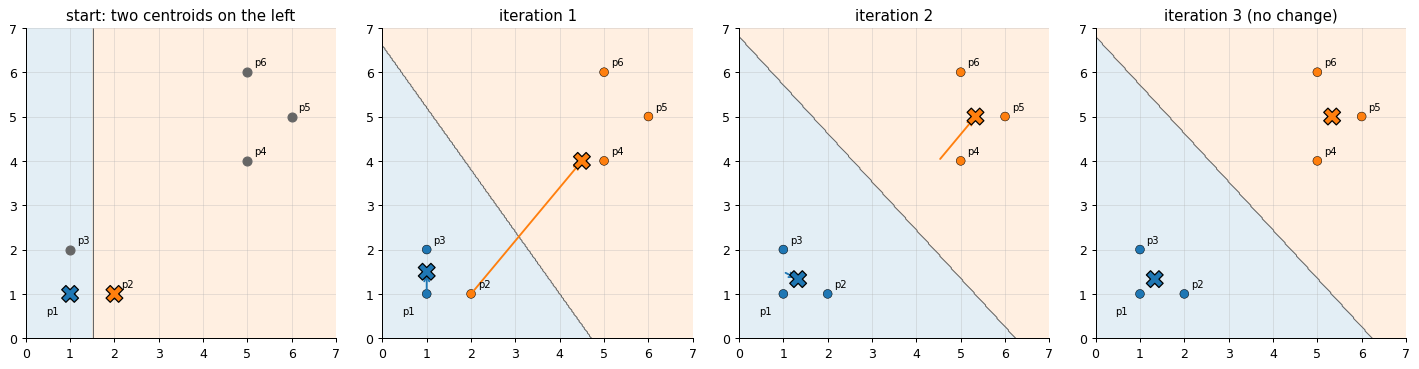

In [5]:
def voronoi_background(ax, C, xlim, ylim, alpha=0.12, res=300):
    # Colour the plane by nearest centroid: the Voronoi cells of the centroids.
    gx, gy = np.meshgrid(np.linspace(*xlim, res), np.linspace(*ylim, res))
    lab, _ = assign(np.c_[gx.ravel(), gy.ravel()], C)
    ax.contourf(gx, gy, lab.reshape(gx.shape), levels=np.arange(len(C) + 1) - 0.5,
                colors=[PALETTE[j % 10] for j in range(len(C))], alpha=alpha)
    ax.contour(gx, gy, lab.reshape(gx.shape), levels=np.arange(len(C)) + 0.5, colors="0.4", linewidths=0.8)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.9))
titles = ["start: two centroids on the left", "iteration 1", "iteration 2", "iteration 3 (no change)"]
J_titles = [None, 23.5, 4.0, 4.0]
for ax, (lab, Cs), t, (lab_prev, C_prev) in zip(axes, steps6 + [steps6[-1]], titles, [steps6[0]] + steps6):
    if lab is None:
        voronoi_background(ax, Cs, (0, 7), (0, 7))
        ax.scatter(X6[:, 0], X6[:, 1], c="0.4", s=50, zorder=3)
    else:
        voronoi_background(ax, Cs, (0, 7), (0, 7))
        ax.scatter(X6[:, 0], X6[:, 1], c=label_colors(lab), s=50, zorder=3, edgecolors="k", linewidths=0.4)
        for j in range(2):        # arrows: where the centroid moved in this update
            ax.annotate("", xy=Cs[j], xytext=C_prev[j], arrowprops=dict(arrowstyle="->", color=PALETTE[j], lw=1.5))
    ax.scatter(Cs[:, 0], Cs[:, 1], marker="X", s=180, c=PALETTE[:2], edgecolors="k", zorder=4)
    for i, p in enumerate(X6):
        dx, dy = (-0.55, -0.45) if i == 0 else (0.15, 0.15)       # p1 sits under the final centroid
        ax.text(p[0] + dx, p[1] + dy, names6[i], fontsize=8)
    ax.set_xlim(0, 7); ax.set_ylim(0, 7); ax.set_aspect("equal"); ax.set_title(t)
plt.tight_layout(); plt.show()

**What just happened?** Both centroids start on the left. In the first assignment p1 and p3 go to $\boldsymbol{\mu}_1$ and the other four, including the whole right group, to $\boldsymbol{\mu}_2$: $J = 85$. The update moves $\boldsymbol{\mu}_2$ to the mean of its four points, $(4.5, 4)$, and $J$ drops to 23.5. Now p2 is closer to $\boldsymbol{\mu}_1$ ($1.25$ against $15.25$ in squared distance): it changes cluster and $J = 9.5$. The second update gives $\boldsymbol{\mu}_1 = (1.333, 1.333)$, $\boldsymbol{\mu}_2 = (5.333, 5)$ and $J = 4$. The third assignment changes nothing, so we stop. The sequence $85 \to 23.5 \to 9.5 \to 4 \to 4$ never goes up, as the proof promised.

The shaded regions are the **Voronoi cells** of the centroids: the set of points of the plane closer to one centroid than to the others. With two centroids the border is the perpendicular bisector of the segment between them; with $k$ centroids the cells are convex polygons. k-means always cuts the space into convex cells, and that is its main limit (section 5).

Now a larger dataset, four blobs of 200 points (`X4`), and a check against scikit-learn's `KMeans` started from the same centroids.

ours        : J = 183.6386 after 4 updates
scikit-learn: J = 183.6386 after 5 iterations
same centroids, same labels, same J: checked;  J never increases: checked
J after each assignment step: [2232.   934.3  717.3  201.   183.6]


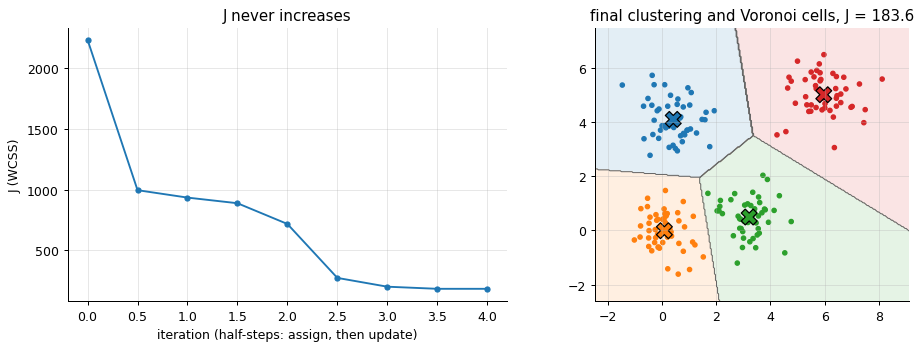

In [6]:
X4, y4 = make_blobs(n_samples=200, centers=[[0, 0], [3, 0.5], [0.5, 4], [6, 5]], cluster_std=0.7, random_state=1)
C0 = X4[np.random.default_rng(0).choice(len(X4), 4, replace=False)]      # 4 random points as the start

lab4, C4, hist4, n_upd = lloyd(X4, C0)
km = KMeans(n_clusters=4, init=C0, n_init=1, algorithm="lloyd", tol=0, max_iter=300).fit(X4)
print(f"ours        : J = {hist4[-1]:.4f} after {n_upd} updates")
print(f"scikit-learn: J = {km.inertia_:.4f} after {km.n_iter_} iterations")
assert np.allclose(km.cluster_centers_, C4) and np.array_equal(km.labels_, lab4) and np.isclose(km.inertia_, hist4[-1])
assert np.all(np.diff(hist4) <= 1e-9)
print("same centroids, same labels, same J: checked;  J never increases: checked")
print("J after each assignment step:", hist4[0::2].round(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.arange(len(hist4)) / 2, hist4, "o-", ms=4)
axes[0].set_xlabel("iteration (half-steps: assign, then update)"); axes[0].set_ylabel("J (WCSS)")
axes[0].set_title("J never increases")
lims = (X4[:, 0].min() - 1, X4[:, 0].max() + 1), (X4[:, 1].min() - 1, X4[:, 1].max() + 1)
voronoi_background(axes[1], C4, *lims)
scatter(axes[1], X4, lab4, f"final clustering and Voronoi cells, J = {hist4[-1]:.1f}", s=12, equal=False)
axes[1].scatter(C4[:, 0], C4[:, 1], marker="X", s=160, c=PALETTE[:4], edgecolors="k")
axes[1].set_xlim(lims[0]); axes[1].set_ylim(lims[1]); axes[1].set_aspect("equal")
plt.tight_layout(); plt.show()

**Interpretation.** From four random data points, Lloyd needs 4 updates: $J$ falls from 2,232 (the first assignment) to 183.6, and the fifth assignment changes nothing. Our implementation and scikit-learn's agree exactly: same centroids, same labels, same $J$ (scikit-learn counts 5 iterations because it also counts the final check). Few iterations are typical: k-means usually converges in a few to a few dozen passes.

**Cost.** One iteration computes $n \cdot k$ distances in $d$ dimensions: $O(nkd)$ time, linear in the number of points. That is why k-means is the workhorse of clustering: millions of points are fine (and section 5 makes it even cheaper with mini-batches).

## 3. Initialisation: local minima and k-means++

Lloyd stops at the first fixed point it reaches. If two centroids start inside the same true cluster, they may split it between them while another centroid has to cover two true clusters, and no single step can fix it. We measure how often this happens on a harder dataset: nine blobs on a $3 \times 3$ grid (`X9`), $k = 9$, 200 runs from 9 random data points ("random" initialisation, also called Forgy).

**k-means++** (Arthur and Vassilvitskii, 2007) chooses the starting centroids one by one, spreading them out:

1. pick the first centroid uniformly at random among the data points;
2. for every point compute $D(\mathbf{x})$, its distance to the **nearest centroid chosen so far**;
3. pick the next centroid at random with probability $\dfrac{D(\mathbf{x})^2}{\sum_{\mathbf{x}'} D(\mathbf{x}')^2}$;
4. repeat 2–3 until there are $k$ centroids, then run Lloyd.

Points far from every current centroid are much more likely to be chosen, but it is still random, so an outlier does not always win. The guarantee: the expected $J$ of the k-means++ **start alone** is at most $8(\ln k + 2)$ times the optimal $J$. scikit-learn uses k-means++ by default.

In [7]:
def kmeans_pp(X, k, rng):
    # k-means++ seeding: each new centre is drawn with probability proportional to D(x)^2.
    centers = [X[rng.integers(len(X))]]
    for _ in range(k - 1):
        D2 = assign(X, np.array(centers))[1].min(1)          # squared distance to the nearest chosen centre
        centers.append(X[rng.choice(len(X), p=D2 / D2.sum())])
    return np.array(centers)

def kmeans(X, k, n_init=10, init="k-means++", seed=0):
    # k-means from scratch: n_init runs of Lloyd, keep the one with the lowest J.
    rng, best = np.random.default_rng(seed), None
    for _ in range(n_init):
        C0 = kmeans_pp(X, k, rng) if init == "k-means++" else X[rng.choice(len(X), k, replace=False)]
        labels, C, hist, _ = lloyd(X, C0)
        if best is None or hist[-1] < best[2]:
            best = (labels, C, hist[-1])
    return best

grid = [[3 * i, 3 * j] for i in range(3) for j in range(3)]
X9, y9 = make_blobs(n_samples=450, centers=grid, cluster_std=0.5, random_state=0)
rng = np.random.default_rng(0)
J_init, J_final, examples = {"random": [], "k-means++": []}, {"random": [], "k-means++": []}, {}
for run in range(200):
    for init in ["random", "k-means++"]:
        C0 = X9[rng.choice(len(X9), 9, replace=False)] if init == "random" else kmeans_pp(X9, 9, rng)
        J_init[init].append(wcss(X9, assign(X9, C0)[0], C0))
        lab, C, hist, _ = lloyd(X9, C0)
        J_final[init].append(hist[-1])
        examples.setdefault(init, []).append((C0, lab, C, hist[-1]))
J_best = min(min(v) for v in J_final.values())
print(f"best J over all 400 runs: {J_best:.2f}")
for init in ["random", "k-means++"]:
    Jf, Ji = np.array(J_final[init]), np.array(J_init[init])
    ok = np.mean(Jf < 1.01 * J_best)
    print(f"{init:10s}: start J / best J = {Ji.mean() / J_best:4.1f} on average;  final J within 1 % of the best in "
          f"{100 * ok:4.1f} % of the runs;  P(at least one good run in 10) = {100 * (1 - (1 - ok) ** 10):5.1f} %")
print(f"the k-means++ bound on the start: 8 (ln 9 + 2) = {8 * (np.log(9) + 2):.1f} times the optimum")
sk9 = KMeans(9, n_init=10, random_state=0).fit(X9)
print(f"scikit-learn KMeans(n_init=10, k-means++): J = {sk9.inertia_:.2f}")

best J over all 400 runs: 217.43
random    : start J / best J =  6.6 on average;  final J within 1 % of the best in 31.5 % of the runs;  P(at least one good run in 10) =  97.7 %
k-means++ : start J / best J =  3.1 on average;  final J within 1 % of the best in 57.0 % of the runs;  P(at least one good run in 10) = 100.0 %
the k-means++ bound on the start: 8 (ln 9 + 2) = 33.6 times the optimum
scikit-learn KMeans(n_init=10, k-means++): J = 217.43


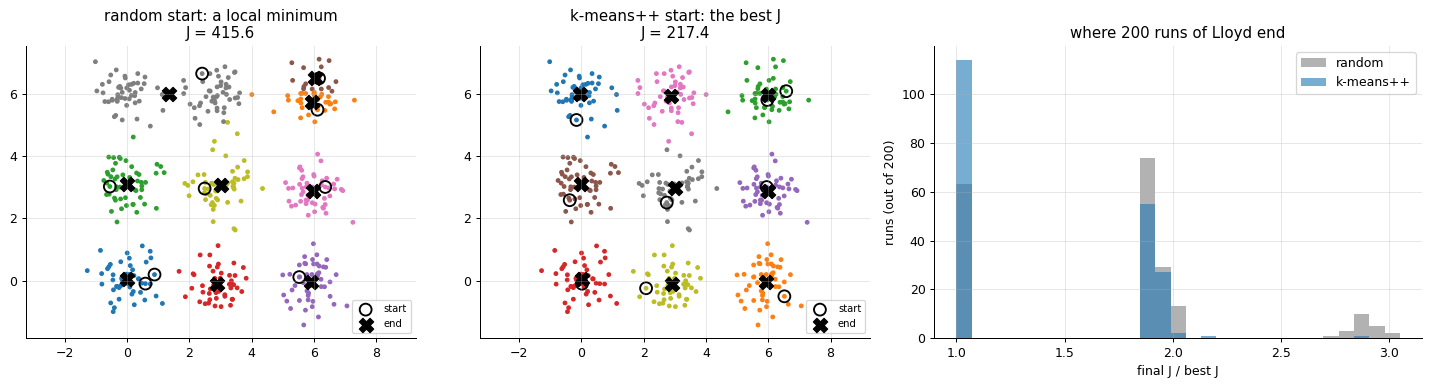

In [8]:
bad = next(e for e in examples["random"] if e[3] > 1.3 * J_best)          # a run stuck in a poor local minimum
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), gridspec_kw={"width_ratios": [1, 1, 1.25]})
for ax, (C0, lab, C, J), t in [(axes[0], bad, "random start: a local minimum"),
                               (axes[1], next(e for e in examples["k-means++"] if e[3] < 1.01 * J_best), "k-means++ start: the best J")]:
    scatter(ax, X9, lab, f"{t}\nJ = {J:.1f}", s=8)
    ax.scatter(C0[:, 0], C0[:, 1], marker="o", s=90, facecolors="none", edgecolors="k", linewidths=1.5, label="start")
    ax.scatter(C[:, 0], C[:, 1], marker="X", s=130, c="k", label="end")
    ax.legend(loc="lower right", fontsize=8)
bins = np.linspace(1, max(max(J_final["random"]), max(J_final["k-means++"])) / J_best, 30)
for init, col in [("random", "tab:gray"), ("k-means++", "tab:blue")]:
    axes[2].hist(np.array(J_final[init]) / J_best, bins=bins, alpha=0.6, color=col, label=init)
axes[2].set_xlabel("final J / best J"); axes[2].set_ylabel("runs (out of 200)")
axes[2].set_title("where 200 runs of Lloyd end"); axes[2].legend()
plt.tight_layout(); plt.show()

**What just happened?** With random starts, only 31.5 % of the 200 runs reach the best $J$ (217.43); the others end in a local minimum like the one on the left, where one centroid sits between two blobs and another pair shares a single blob. k-means++ reaches the best solution in 57.0 % of the runs. Its start is also much better before Lloyd even begins: on average 3.1 times the best $J$, against 6.6 times for random points (the theoretical bound, 33.6, is loose).

**In practice.** Never trust a single run. Run k-means several times and keep the lowest $J$: this is `n_init` in scikit-learn. With 10 runs, the chance that at least one is good is 97.7 % with random starts and 99.98 % with k-means++. scikit-learn's `KMeans(n_init=10)` finds $J$ = 217.43. Note that recent versions of scikit-learn use `n_init="auto"`, which means **a single run** with k-means++: set `n_init` explicitly when the clusters are not obvious.

## 4. Choosing $k$: the elbow and the silhouette

$J$ cannot choose $k$: it always decreases when $k$ grows (the best solution with $k + 1$ centroids is at least as good as the best with $k$, keep the old centroids and add one anywhere), and $J = 0$ when every point is its own cluster. Two classic tools:

- **The elbow.** Plot the best $J$ against $k$ and look for the $k$ after which the curve flattens: adding a centroid no longer buys much.
- **The silhouette** (Rousseeuw, 1987). For each point $i$ in cluster $C$:
  - $a(i)$ = the mean distance from $i$ to the **other points of its own cluster** (how tight its cluster is around it);
  - $b(i)$ = the smallest, over the other clusters $C'$, of the mean distance from $i$ to the points of $C'$ (how far the **nearest other cluster** is);
  - $s(i) = \dfrac{b(i) - a(i)}{\max(a(i), b(i))} \in [-1, 1]$, and $s(i) = 0$ by convention if $i$ is alone in its cluster.

$s(i)$ close to 1: well inside its cluster. Close to 0: on the border between two clusters. Negative: probably in the wrong cluster. The **mean silhouette** over all points scores the whole clustering; we pick the $k$ that maximises it. It costs all pairwise distances, $O(n^2 d)$.

Worked example on the six points of section 2 with the final clustering $\{p_1, p_2, p_3\}$, $\{p_4, p_5, p_6\}$. For $p_2 = (2, 1)$: its own cluster mates are at distances 1 and $\sqrt{2} = 1.414$, so $a = 1.207$; the other cluster is at $\sqrt{18} = 4.243$, $\sqrt{32} = 5.657$ and $\sqrt{34} = 5.831$, so $b = 5.243$; $s = (5.243 - 1.207)/5.243 = 0.770$.

In [9]:
def silhouette(X, labels):
    # Silhouette values s(i), and a(i), b(i), from the full pairwise distance matrix.
    D = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(-1))
    ks = np.unique(labels)
    own = np.searchsorted(ks, labels)                                   # index of the own cluster
    sizes = np.array([(labels == j).sum() for j in ks])
    S = np.stack([D[:, labels == j].sum(1) for j in ks], axis=1)       # n x k: sum of distances to each cluster
    idx = np.arange(len(X))
    a = S[idx, own] / np.maximum(sizes[own] - 1, 1)                     # own cluster, without the point itself
    M = S / sizes                                                       # mean distance to each cluster
    M[idx, own] = np.inf
    b = M.min(1)                                                        # nearest other cluster
    s = np.where(sizes[own] > 1, (b - a) / np.maximum(a, b), 0.0)
    return s, a, b

s6, a6, b6 = silhouette(X6, lab6)
print(f"p2: a = {a6[1]:.3f}, b = {b6[1]:.3f}, s = {s6[1]:.3f}   (expected 1.207, 5.243, 0.770)")
print("s(i) of the six points:", s6.round(3), f"  mean = {s6.mean():.3f}")
assert np.allclose(s6, silhouette_samples(X6, lab6))

ks = range(2, 9)
J_k, sil_k, fits = [], [], {}
for k in range(1, 9):
    m = KMeans(k, n_init=10, random_state=0).fit(X4)
    fits[k] = m
    J_k.append(m.inertia_)
    if k > 1:
        s = silhouette(X4, m.labels_)[0]
        assert np.isclose(s.mean(), silhouette_score(X4, m.labels_))
        sil_k.append(s.mean())
print("our silhouette = scikit-learn's silhouette_score for every k: checked")
for k in range(1, 9):
    print(f"k = {k}:  J = {J_k[k - 1]:8.1f}" + (f"   mean silhouette = {sil_k[k - 2]:.3f}" if k > 1 else ""))
best_k = 2 + int(np.argmax(sil_k))
print("best k by the silhouette:", best_k, "  (4 blobs were generated)")

p2: a = 1.207, b = 5.243, s = 0.770   (expected 1.207, 5.243, 0.770)
s(i) of the six points: [0.832 0.77  0.773 0.627 0.763 0.714]   mean = 0.746


our silhouette = scikit-learn's silhouette_score for every k: checked
k = 1:  J =   2269.1
k = 2:  J =    979.0   mean silhouette = 0.560
k = 3:  J =    434.1   mean silhouette = 0.610
k = 4:  J =    183.6   mean silhouette = 0.680
k = 5:  J =    163.5   mean silhouette = 0.572
k = 6:  J =    146.3   mean silhouette = 0.491
k = 7:  J =    129.1   mean silhouette = 0.411
k = 8:  J =    118.7   mean silhouette = 0.394
best k by the silhouette: 4   (4 blobs were generated)


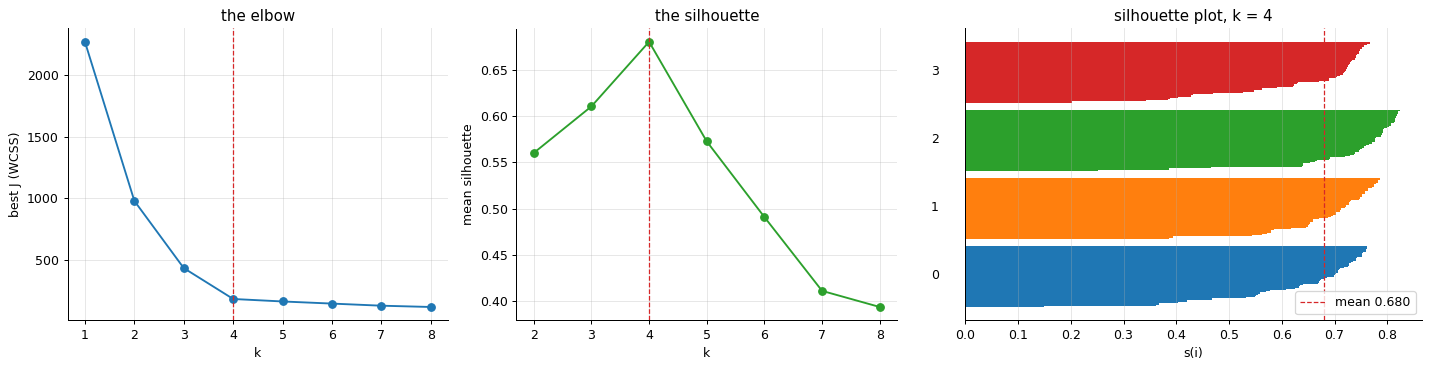

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), gridspec_kw={"width_ratios": [1, 1, 1.2]})
axes[0].plot(range(1, 9), J_k, "o-"); axes[0].axvline(best_k, color="tab:red", ls="--", lw=1)
axes[0].set_xlabel("k"); axes[0].set_ylabel("best J (WCSS)"); axes[0].set_title("the elbow")
axes[1].plot(list(ks), sil_k, "o-", color="tab:green"); axes[1].axvline(best_k, color="tab:red", ls="--", lw=1)
axes[1].set_xlabel("k"); axes[1].set_ylabel("mean silhouette"); axes[1].set_title("the silhouette")
s, _, _ = silhouette(X4, fits[best_k].labels_)
y0 = 0
for j in range(best_k):
    sj = np.sort(s[fits[best_k].labels_ == j])
    axes[2].barh(np.arange(y0, y0 + len(sj)), sj, height=1.0, color=PALETTE[j], edgecolor="none")
    axes[2].text(-0.05, y0 + len(sj) / 2, str(j), ha="right", va="center")
    y0 += len(sj) + 6
axes[2].axvline(s.mean(), color="tab:red", ls="--", lw=1, label=f"mean {s.mean():.3f}")
axes[2].set_xlabel("s(i)"); axes[2].set_yticks([]); axes[2].set_title(f"silhouette plot, k = {best_k}"); axes[2].legend()
plt.tight_layout(); plt.show()

**What just happened?** The worked example checks out: $p_2$ has $a = 1.207$, $b = 5.243$, $s = 0.770$, and our function agrees with `silhouette_samples` everywhere. On the four blobs, $J$ drops steeply up to $k = 4$ (434.1 at $k = 3$, 183.6 at $k = 4$) and only slowly after (163.5 at $k = 5$): the elbow is at 4. The mean silhouette peaks at $k = 4$ too (0.680, against 0.610 for $k = 3$ and 0.572 for $k = 5$). In the silhouette plot almost every bar is long and positive; the few short bars belong to the two blobs that touch, at $(0, 0)$ and $(3, 0.5)$.

**Caveats.** The elbow is often not sharp on real data, and the silhouette, like $J$, rewards compact round clusters (section 10 shows it preferring a wrong answer on the moons). Use them as hints, together with stability (section 10) and, above all, with what the clusters mean for the problem.

## 5. What k-means assumes; mini-batch k-means; colour quantisation

Every k-means cluster is a convex Voronoi cell, and the border between two clusters is the perpendicular bisector of their centroids. Implicitly k-means assumes clusters that are **convex**, **isotropic** (round, the same spread in every direction) and of **similar size and spread**. Section 6 makes this precise: k-means is a Gaussian mixture with equal round covariances. When these assumptions fail, k-means still returns $k$ clusters, just the wrong ones.

aniso    k-means (ours, k-means++, 10 runs): ARI with the generating groups = 0.572
varied   k-means (ours, k-means++, 10 runs): ARI with the generating groups = 0.731
moons    k-means (ours, k-means++, 10 runs): ARI with the generating groups = 0.483
circles  k-means (ours, k-means++, 10 runs): ARI with the generating groups = -0.002


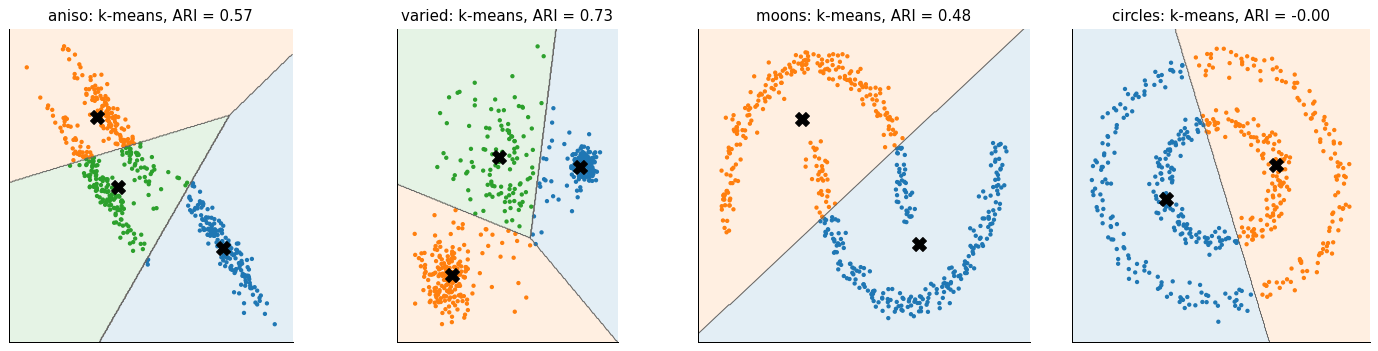

In [11]:
fail_sets = ["aniso", "varied", "moons", "circles"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.0))
for ax, name in zip(axes, fail_sets):
    X, y = toy[name]
    lab, C, J = kmeans(X, k_toy[name], n_init=10, seed=0)
    ari = adjusted_rand_score(y, lab)
    lims = (X[:, 0].min() - 0.3, X[:, 0].max() + 0.3), (X[:, 1].min() - 0.3, X[:, 1].max() + 0.3)
    voronoi_background(ax, C, *lims)
    scatter(ax, X, lab, f"{name}: k-means, ARI = {ari:.2f}", s=6, equal=False)
    ax.scatter(C[:, 0], C[:, 1], marker="X", s=120, c="k")
    ax.set_xlim(lims[0]); ax.set_ylim(lims[1]); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    print(f"{name:8s} k-means (ours, k-means++, 10 runs): ARI with the generating groups = {ari:.3f}")
plt.tight_layout(); plt.show()

**Things to notice.**
- **aniso**: the clusters are long tilted ellipses; the straight Voronoi borders cut across them. ARI 0.57.
- **varied**: the wide cluster is cut, and its outer points go to the tight neighbours, because the border is halfway between centroids, whatever the spreads. ARI 0.73.
- **moons** and **circles**: no centroid can describe a crescent or a ring. k-means cuts the moons with a straight line and the circles into two half-rings. ARI 0.48 and 0.00.

Fixes: a Gaussian mixture with full covariances for ellipses and different spreads (section 6), density or graph methods for arbitrary shapes (sections 8 and 9), or a better representation of the data before k-means (section 11).

### Mini-batch k-means

Each Lloyd iteration reads all $n$ points. **Mini-batch k-means** (Sculley, 2010) updates the centroids from a small random batch at a time. Each centroid keeps a count $N_j$ of the points it has absorbed so far; a batch point $\mathbf{x}$ assigned to centroid $j$ moves it by

$$
N_j \leftarrow N_j + 1, \qquad \boldsymbol{\mu}_j \leftarrow \boldsymbol{\mu}_j + \frac{1}{N_j}\,(\mathbf{x} - \boldsymbol{\mu}_j) ,
$$

a stochastic gradient step on $J$ with a per-centroid learning rate $1/N_j$. With this rate, $\boldsymbol{\mu}_j$ is exactly the running mean of all the points it was ever assigned. We implement it (vectorised per batch: adding the $m_j$ batch points one by one is the same as $\boldsymbol{\mu}_j \leftarrow (N_j\boldsymbol{\mu}_j + \sum \mathbf{x})/(N_j + m_j)$) and compare it with full Lloyd and with scikit-learn on 200,000 points in 10 dimensions.

In [12]:
def minibatch_kmeans(X, C0, batch_size=1024, n_steps=100, seed=0):
    # Mini-batch k-means: each centroid is the running mean of the batch points assigned to it.
    rng = np.random.default_rng(seed)
    C, counts = np.array(C0, dtype=float), np.zeros(len(C0))
    for _ in range(n_steps):
        B = X[rng.choice(len(X), batch_size, replace=False)]
        lab, _ = assign(B, C)
        for j in np.unique(lab):
            pts = B[lab == j]
            C[j] = (counts[j] * C[j] + pts.sum(0)) / (counts[j] + len(pts))   # = m_j steps of size 1/N_j
            counts[j] += len(pts)
    return C

X_big, _ = make_blobs(n_samples=200_000, centers=8, n_features=10, cluster_std=1.0, random_state=0)
C0_big = kmeans_pp(X_big[:5000], 8, np.random.default_rng(0))      # the same start for both methods
t0 = time.time(); lab_full, C_full, hist_full, it_full = lloyd(X_big, C0_big); t_full = time.time() - t0
t0 = time.time(); C_mb = minibatch_kmeans(X_big, C0_big); t_mb = time.time() - t0
J_full = hist_full[-1]
J_mb = wcss(X_big, assign(X_big, C_mb)[0], C_mb)
print(f"full Lloyd (ours)     : {it_full} passes over 200,000 points, {t_full:5.2f} s, J = {J_full:,.0f}")
print(f"mini-batch (ours)     : 100 batches of 1,024 points, {t_mb:5.2f} s, J = {J_mb:,.0f}  ({100 * (J_mb / J_full - 1):.2f} % above)")
t0 = time.time(); sk_full = KMeans(8, init=C0_big, n_init=1).fit(X_big); t_skf = time.time() - t0
t0 = time.time(); sk_mb = MiniBatchKMeans(8, init=C0_big, n_init=1, batch_size=1024, random_state=0).fit(X_big); t_skm = time.time() - t0
print(f"scikit-learn KMeans   : {t_skf:5.2f} s, J = {sk_full.inertia_:,.0f}")
print(f"scikit-learn MiniBatch: {t_skm:5.2f} s, J = {sk_mb.inertia_:,.0f}  ({100 * (sk_mb.inertia_ / sk_full.inertia_ - 1):.2f} % above)")

full Lloyd (ours)     : 3 passes over 200,000 points,  0.35 s, J = 1,997,522
mini-batch (ours)     : 100 batches of 1,024 points,  0.04 s, J = 1,997,947  (0.02 % above)
scikit-learn KMeans   :  0.03 s, J = 1,997,522
scikit-learn MiniBatch:  0.11 s, J = 1,997,571  (0.00 % above)


**Interpretation.** Our mini-batch version sees $100 \times 1{,}024 = 102{,}400$ points in total, about half of one pass over the data, and ends with a $J$ only 0.02 % above full Lloyd, which needed 3 complete passes plus the final check. The printed timings depend on the machine and vary from run to run (mini-batch is many times faster here); what matters is that the cost of mini-batch k-means is set by the number of batches, not by $n$. Use it when $n$ is in the millions or the data arrive as a stream; the price is a slightly worse $J$ and more noise from run to run.

### Colour quantisation: k-means as compression

A colour image is a cloud of points in RGB space, one point per pixel. Run k-means with $k$ clusters on the pixels and replace every pixel by its centroid: the image now uses $k$ colours, each pixel can be stored as an index of $\log_2 k$ bits instead of 24, plus a palette of $k$ colours. We use the photo `china.jpg` bundled with scikit-learn ($427 \times 640$ pixels). k-means is fitted on a random sample of 10,000 pixels, then every pixel is assigned to its nearest centroid (`predict`, our `assign`).

image (427, 640, 3), 273,280 pixels, 96,615 distinct colours
k =   2: 1 bits per pixel, compression  24.0 x, RMSE  35.8 (on 0-255)
k =   4: 2 bits per pixel, compression  12.0 x, RMSE  21.4 (on 0-255)
k =   8: 3 bits per pixel, compression   8.0 x, RMSE  14.6 (on 0-255)


k =  16: 4 bits per pixel, compression   6.0 x, RMSE  10.7 (on 0-255)


k =  64: 6 bits per pixel, compression   4.0 x, RMSE   6.2 (on 0-255)


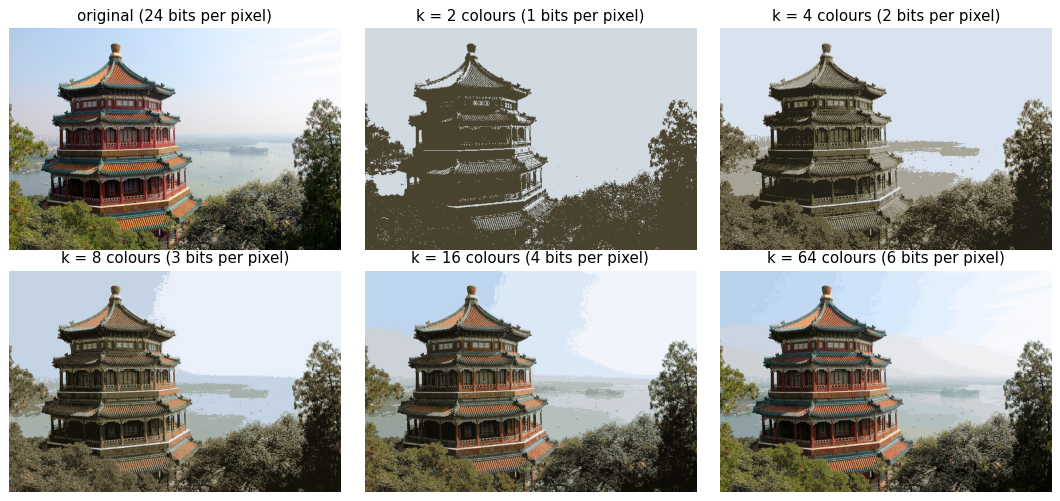

In [13]:
china = load_sample_image("china.jpg")                       # 427 x 640 x 3, uint8, bundled with scikit-learn
pixels = china.reshape(-1, 3).astype(float) / 255
sample = pixels[np.random.default_rng(0).choice(len(pixels), 10_000, replace=False)]
print(f"image {china.shape}, {len(pixels):,} pixels, {len(np.unique(china.reshape(-1, 3), axis=0)):,} distinct colours")

ks_img = [2, 4, 8, 16, 64]
quant, rows = {}, []
for k in ks_img:
    km_img = KMeans(k, n_init=3, random_state=0).fit(sample)
    lab_img, _ = assign(pixels, km_img.cluster_centers_)
    assert np.array_equal(lab_img, km_img.predict(pixels))
    quant[k] = km_img.cluster_centers_[lab_img].reshape(china.shape)
    rmse = 255 * np.sqrt(((quant[k].reshape(-1, 3) - pixels) ** 2).mean())
    bits = len(pixels) * np.log2(k) + 24 * k                  # indices + palette
    rows.append((k, np.log2(k), 24 * len(pixels) / bits, rmse))
    print(f"k = {k:3d}: {np.log2(k):.0f} bits per pixel, compression {24 * len(pixels) / bits:5.1f} x, "
          f"RMSE {rmse:5.1f} (on 0-255)")

fig, axes = plt.subplots(2, 3, figsize=(12, 5.6))
axes = axes.ravel()
axes[0].imshow(china); axes[0].set_title("original (24 bits per pixel)")
for ax, k in zip(axes[1:], ks_img):
    ax.imshow(quant[k]); ax.set_title(f"k = {k} colours ({np.log2(k):.0f} bits per pixel)")
for ax in axes:
    ax.axis("off")
plt.tight_layout(); plt.show()

**What just happened?** With 16 colours the photo is hard to tell from the original (RMSE 10.7 grey levels out of 255) and takes 6 times less space; with 64 colours (RMSE 6.2) the difference is barely visible. With 2 or 4 colours the image becomes a poster. k-means puts the palette where the pixels are: many shades of the dominant colours (sky, stone, foliage) and none for colours that do not occur. This is how GIF and PNG-8 palettes, and many "posterise" filters, are built.

## 6. Gaussian mixtures and EM from scratch

**The generative story.** A Gaussian mixture model (GMM) says each point was produced in two steps: pick a component $j$ with probability $\pi_j$ (the mixing weights, $\sum_j \pi_j = 1$), then draw $\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)$. The density of a point is

$$
p(\mathbf{x}) = \sum_{j=1}^{k} \pi_j\, \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j), \qquad
\ell(\boldsymbol{\theta}) = \sum_{i=1}^{n} \log \sum_{j=1}^{k} \pi_j\, \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j) .
$$

The cluster of a point is the hidden component that produced it. By Bayes' rule, the probability that point $i$ came from component $j$, its **responsibility**, is

$$
\gamma_{ij} = P(j \mid \mathbf{x}_i) = \frac{\pi_j\, \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}{\sum_{l} \pi_l\, \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_l, \boldsymbol{\Sigma}_l)} .
$$

This is a **soft** clustering: a point between two components can be 60/40. The log of a sum has no closed-form maximum, but if we knew the responsibilities, the maximum would be easy: a weighted version of the usual Gaussian estimates. **Expectation–maximisation** (EM, Dempster, Laird and Rubin, 1977) alternates:

- **E-step**: compute $\gamma_{ij}$ with the current parameters (the formula above).
- **M-step**: with $N_j = \sum_i \gamma_{ij}$ (the "number of points" of component $j$, not an integer),
$$
\pi_j = \frac{N_j}{n}, \qquad \boldsymbol{\mu}_j = \frac{1}{N_j}\sum_i \gamma_{ij}\,\mathbf{x}_i, \qquad \boldsymbol{\Sigma}_j = \frac{1}{N_j}\sum_i \gamma_{ij}\,(\mathbf{x}_i - \boldsymbol{\mu}_j)(\mathbf{x}_i - \boldsymbol{\mu}_j)^\top .
$$

**Where the M-step comes from.** With the responsibilities fixed, EM maximises $Q(\boldsymbol{\theta}) = \sum_i \sum_j \gamma_{ij}\,\big[\log \pi_j + \log \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)\big]$. For each $j$, the Gaussian part is a weighted Gaussian log-likelihood: setting the gradient with respect to $\boldsymbol{\mu}_j$ to zero, $\sum_i \gamma_{ij}\boldsymbol{\Sigma}_j^{-1}(\mathbf{x}_i - \boldsymbol{\mu}_j) = \mathbf{0}$, gives the weighted mean, and the same with respect to $\boldsymbol{\Sigma}_j$ gives the weighted covariance. For the weights, maximise $\sum_j N_j \log \pi_j$ subject to $\sum_j \pi_j = 1$: a Lagrange multiplier gives $\pi_j \propto N_j$.

**Why the likelihood never decreases (proof).** For any probabilities $q_{i1}, \dots, q_{ik}$ over the components of point $i$, Jensen's inequality ($\log$ is concave) gives

$$
\log p(\mathbf{x}_i) = \log \sum_j q_{ij}\,\frac{\pi_j \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}{q_{ij}} \;\ge\; \sum_j q_{ij} \log \frac{\pi_j \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}{q_{ij}} ,
$$

with equality when the ratio inside does not depend on $j$, that is when $q_{ij} = \gamma_{ij}$. Summing over $i$: $\ell(\boldsymbol{\theta}) \ge B(q, \boldsymbol{\theta})$ for every $q$. The E-step sets $q = \gamma(\boldsymbol{\theta}_{\text{old}})$, so $B(q, \boldsymbol{\theta}_{\text{old}}) = \ell(\boldsymbol{\theta}_{\text{old}})$. The M-step maximises $B(q, \cdot)$ (it is $Q$ plus a constant), so $B(q, \boldsymbol{\theta}_{\text{new}}) \ge B(q, \boldsymbol{\theta}_{\text{old}})$. Hence $\ell(\boldsymbol{\theta}_{\text{new}}) \ge B(q, \boldsymbol{\theta}_{\text{new}}) \ge B(q, \boldsymbol{\theta}_{\text{old}}) = \ell(\boldsymbol{\theta}_{\text{old}})$. $\blacksquare$

Like Lloyd, EM climbs to a local maximum. Our data: 300 points from three Gaussians with different shapes and weights 0.5, 0.33, 0.17.

In [14]:
rng = np.random.default_rng(3)
mu_true = np.array([[0, 0], [4, 3], [5, -1.5]])
Sigma_true = np.array([[[1.0, 0.6], [0.6, 0.8]], [[0.5, -0.3], [-0.3, 1.2]], [[0.3, 0.0], [0.0, 0.3]]])
n_true = [150, 100, 50]
Xg = np.vstack([rng.multivariate_normal(m, S, n) for m, S, n in zip(mu_true, Sigma_true, n_true)])
yg = np.repeat([0, 1, 2], n_true)

def log_gauss(X, mu, S):
    # log N(x | mu, S) for every row of X, via a Cholesky factor S = L L^T.
    L = np.linalg.cholesky(S)
    z = np.linalg.solve(L, (X - mu).T)                    # whitened deviations, d x n
    return -0.5 * (z ** 2).sum(0) - np.log(np.diag(L)).sum() - 0.5 * X.shape[1] * np.log(2 * np.pi)

def e_step(X, pi, mu, Sigma):
    # Responsibilities gamma (n x k) and log p(x_i), with log-sum-exp for stability.
    logp = np.stack([np.log(pi[j]) + log_gauss(X, mu[j], Sigma[j]) for j in range(len(pi))], axis=1)
    log_px = logsumexp(logp, axis=1)
    return np.exp(logp - log_px[:, None]), log_px

def m_step(X, gamma):
    Nk = gamma.sum(0)
    pi = Nk / len(X)
    mu = gamma.T @ X / Nk[:, None]
    Sigma = np.array([(gamma[:, j, None] * (X - mu[j])).T @ (X - mu[j]) / Nk[j] for j in range(len(Nk))])
    return pi, mu, Sigma

def em_gmm(X, pi, mu, Sigma, max_iter=500, tol=1e-8):
    # EM for a Gaussian mixture. Returns the final parameters, the log-likelihood history and snapshots.
    ll, snaps = [], []
    for it in range(max_iter):
        gamma, log_px = e_step(X, pi, mu, Sigma)
        ll.append(log_px.sum())                            # log-likelihood of the current parameters
        snaps.append((pi.copy(), mu.copy(), Sigma.copy(), gamma))
        if it > 0 and ll[-1] - ll[-2] < tol:
            break
        pi, mu, Sigma = m_step(X, gamma)
    return pi, mu, Sigma, np.array(ll), snaps

r0 = np.random.default_rng(1)
mu0 = Xg[r0.choice(len(Xg), 3, replace=False)]            # 3 random points as the initial means
Sigma0 = np.array([np.eye(2) * Xg.var(0).mean()] * 3)      # round, as wide as the data
pi0 = np.ones(3) / 3
pi_em, mu_em, Sigma_em, ll_em, snaps = em_gmm(Xg, pi0, mu0, Sigma0)

assert np.all(np.diff(ll_em) >= -1e-9), "the log-likelihood must never decrease"
print(f"EM: {len(ll_em) - 1} iterations; log-likelihood {ll_em[0]:.2f} -> {ll_em[-1]:.2f}; never decreases: checked")
for it in [0, 1, 2, 5, 10, 20, len(ll_em) - 1]:
    print(f"  iteration {it:2d}: l = {ll_em[it]:9.3f}")
print("weights:", pi_em.round(3), "  (true 0.5, 0.333, 0.167)")
finals = []
for s in range(8):                                         # the same recipe from 8 different random starts
    r = np.random.default_rng(s)
    finals.append(em_gmm(Xg, pi0, Xg[r.choice(len(Xg), 3, replace=False)], Sigma0)[3][-1])
print("final log-likelihood from 8 random starts:", np.round(finals, 2))
print("means:\n", mu_em.round(2))

gm = GaussianMixture(3, covariance_type="full", weights_init=pi0, means_init=mu0,
                     precisions_init=np.linalg.inv(Sigma0), reg_covar=0.0, tol=1e-10, max_iter=1000).fit(Xg)
gamma_end = snaps[-1][3]
print(f"\nmean log-likelihood per point: ours {ll_em[-1] / len(Xg):.6f}, scikit-learn {gm.score(Xg):.6f}")
assert abs(ll_em[-1] / len(Xg) - gm.score(Xg)) < 1e-6 and np.allclose(gm.means_, mu_em, atol=1e-4)
print("same log-likelihood and means as GaussianMixture: checked;",
      f"ARI(ours, scikit-learn) = {adjusted_rand_score(gamma_end.argmax(1), gm.predict(Xg)):.3f}",
      f"; ARI with the true components = {adjusted_rand_score(yg, gamma_end.argmax(1)):.3f}")

EM: 43 iterations; log-likelihood -1385.02 -> -984.54; never decreases: checked
  iteration  0: l = -1385.023
  iteration  1: l = -1229.706
  iteration  2: l = -1131.850
  iteration  5: l = -1037.767
  iteration 10: l = -1037.204
  iteration 20: l = -1035.812
  iteration 43: l =  -984.545
weights: [0.325 0.507 0.168]   (true 0.5, 0.333, 0.167)
final log-likelihood from 8 random starts: [ -984.54  -984.54  -984.54 -1032.66  -984.54  -984.54  -984.54 -1087.32]
means:
 [[ 4.13  3.04]
 [-0.02  0.01]
 [ 4.96 -1.32]]

mean log-likelihood per point: ours -3.281815, scikit-learn -3.281815
same log-likelihood and means as GaussianMixture: checked; ARI(ours, scikit-learn) = 1.000 ; ARI with the true components = 0.970


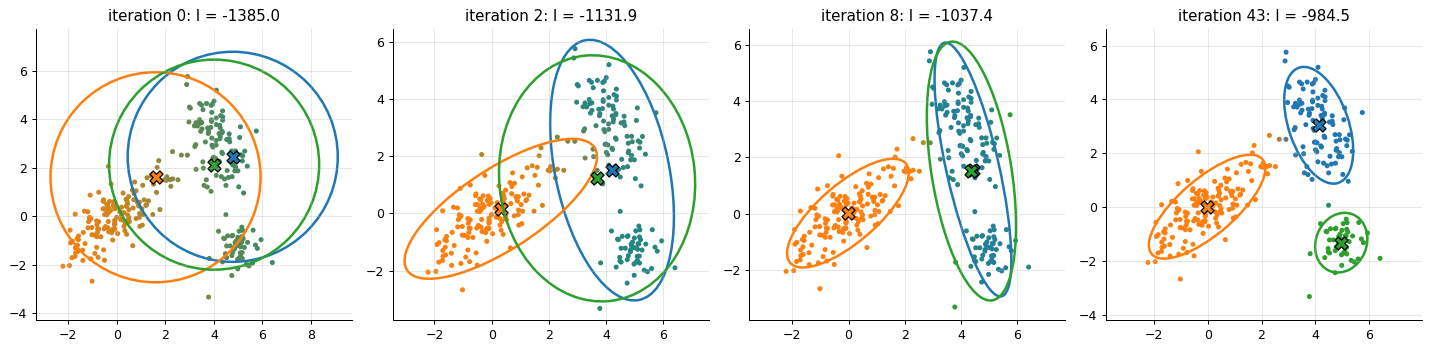

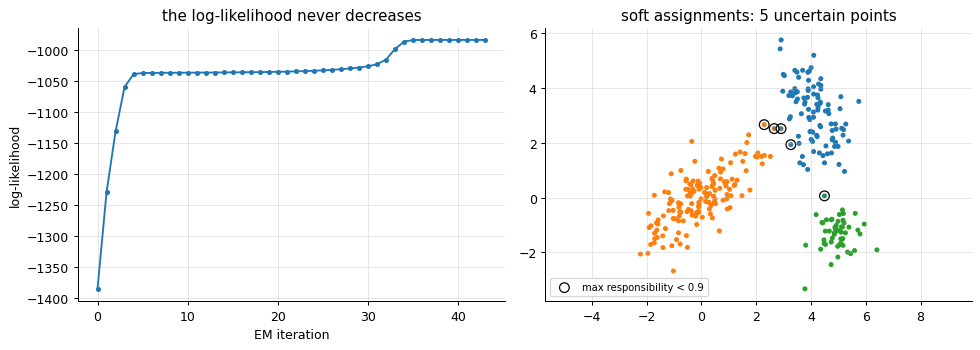

In [15]:
def draw_ellipse(ax, mu, S, color, nsig=2.0, **kw):
    # Ellipse containing the points within nsig standard deviations (Mahalanobis distance nsig).
    vals, vecs = np.linalg.eigh(S)
    angle = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
    ax.add_patch(Ellipse(mu, 2 * nsig * np.sqrt(vals[1]), 2 * nsig * np.sqrt(vals[0]), angle=angle,
                         fill=False, color=color, lw=2, **kw))

def resp_colors(gamma):
    # Mix the component colours with the responsibilities: a 50/50 point gets an intermediate colour.
    return np.clip(gamma @ PALETTE[:gamma.shape[1]], 0, 1)

show_it = [0, 2, 8, len(ll_em) - 1]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.0))
for ax, it in zip(axes, show_it):
    pi_, mu_, S_, gamma_ = snaps[it]
    ax.scatter(Xg[:, 0], Xg[:, 1], s=9, c=resp_colors(gamma_))
    for j in range(3):
        draw_ellipse(ax, mu_[j], S_[j], PALETTE[j])
        ax.scatter(*mu_[j], marker="X", s=110, c=[PALETTE[j]], edgecolors="k")
    ax.set_title(f"iteration {it}: l = {ll_em[it]:.1f}"); ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout(); plt.show()

uncertain = gamma_end.max(1) < 0.9
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ll_em, "o-", ms=3); axes[0].set_xlabel("EM iteration"); axes[0].set_ylabel("log-likelihood")
axes[0].set_title("the log-likelihood never decreases")
axes[1].scatter(Xg[:, 0], Xg[:, 1], s=9, c=resp_colors(gamma_end))
axes[1].scatter(Xg[uncertain, 0], Xg[uncertain, 1], s=60, facecolors="none", edgecolors="k", label="max responsibility < 0.9")
axes[1].set_title(f"soft assignments: {uncertain.sum()} uncertain points"); axes[1].legend(loc="lower left", fontsize=8)
axes[1].set_aspect("equal", adjustable="datalim")
plt.tight_layout(); plt.show()

**What just happened?** EM starts from three random points with round covariances as wide as the data ($\ell = -1385.0$). In five iterations the orange component settles on the big tilted cluster and $\ell$ climbs to $-1037.8$. Then comes a **plateau**: the blue and green components both sit on the two right-hand clusters, one long ellipse on top of the other (iteration 8), and $\ell$ creeps from $-1037.8$ to $-1035.8$ in 15 iterations. Around iteration 30 they separate, $\ell$ jumps, and after 43 iterations the increase falls below $10^{-8}$ at $\ell = -984.5$. The `assert` confirms the theorem: the log-likelihood never went down. The estimated weights (0.325, 0.507, 0.168, in another order) are close to the true 0.5, 0.33, 0.17. scikit-learn's `GaussianMixture` from the same start reaches the same mean log-likelihood per point ($-3.2818$) and the same means.

**Soft assignments are information.** 5 points have no component above 0.9: they sit between the clusters. A hard method gives them a label with the same confidence as a point in the centre; a GMM tells you they are ambiguous, which is useful downstream (send them to a human, or keep the probabilities as features). The ARI with the true components is 0.970: the few disagreements are points of one Gaussian that fell deep into another one, where no method could recover them.

**EM has local maxima too.** From 8 random starts, 6 reach $\ell = -984.54$ and 2 stop for good at $-1032.66$ and $-1087.32$: two components share one cluster and nothing pulls them apart. scikit-learn starts EM from a k-means solution by default (`init_params="kmeans"`) and offers `n_init` to keep the best of several runs.

### k-means is the hard limit of EM

Take a GMM with equal weights $\pi_j = 1/k$ and the same round covariance $\boldsymbol{\Sigma}_j = \sigma^2 \mathbf{I}$ for all components, $\sigma$ fixed. Then

$$
\gamma_{ij} = \frac{\exp\big(-\lVert \mathbf{x}_i - \boldsymbol{\mu}_j \rVert^2 / 2\sigma^2\big)}{\sum_l \exp\big(-\lVert \mathbf{x}_i - \boldsymbol{\mu}_l \rVert^2 / 2\sigma^2\big)} ,
$$

a softmax of minus the squared distances with temperature $2\sigma^2$. As $\sigma \to 0$ the softmax becomes an arg max: $\gamma_{ij} \to 1$ for the nearest centroid and 0 for the others. The E-step becomes the k-means assignment step, and the M-step for the means becomes the k-means update (the mean of the points assigned with weight 1). So **k-means is EM for a mixture of equal, round, infinitely narrow Gaussians**. That is exactly why it assumes round clusters of equal spread, and why a GMM with free covariances fixes the *aniso* and *varied* cases. We check it on the four blobs `X4`.

In [16]:
def soft_kmeans(X, C0, sigma, n_iter=100):
    # EM with equal weights and a fixed shared covariance sigma^2 I: only the means are learned.
    C = np.array(C0, dtype=float)
    for _ in range(n_iter):
        logits = -assign(X, C)[1] / (2 * sigma ** 2)
        gamma = np.exp(logits - logsumexp(logits, axis=1, keepdims=True))
        C = gamma.T @ X / gamma.sum(0)[:, None]
    return C, gamma

C0_4 = kmeans_pp(X4, 4, np.random.default_rng(0))     # a start from which Lloyd reaches the best J
lab_km4, C_km4, _, _ = lloyd(X4, C0_4)
for sigma in [3.0, 1.5, 1.0, 0.5, 0.2, 0.05]:
    C_s, gamma_s = soft_kmeans(X4, C0_4, sigma)
    print(f"sigma = {sigma:4.2f}: mean max responsibility {gamma_s.max(1).mean():.3f};  "
          f"ARI with k-means {adjusted_rand_score(lab_km4, gamma_s.argmax(1)):.3f};  "
          f"max |centre - k-means centre| = {np.abs(C_s - C_km4).max():.4f}")

sigma = 3.00: mean max responsibility 0.250;  ARI with k-means 0.274;  max |centre - k-means centre| = 3.5426
sigma = 1.50: mean max responsibility 0.855;  ARI with k-means 1.000;  max |centre - k-means centre| = 0.5921
sigma = 1.00: mean max responsibility 0.982;  ARI with k-means 1.000;  max |centre - k-means centre| = 0.0495
sigma = 0.50: mean max responsibility 1.000;  ARI with k-means 1.000;  max |centre - k-means centre| = 0.0021
sigma = 0.20: mean max responsibility 1.000;  ARI with k-means 1.000;  max |centre - k-means centre| = 0.0000
sigma = 0.05: mean max responsibility 1.000;  ARI with k-means 1.000;  max |centre - k-means centre| = 0.0000


**Interpretation.** With a wide $\sigma$ = 3 every point is shared among the components (mean max responsibility 0.250, the minimum possible with 4 components) and the means collapse towards the centre of the data. As $\sigma$ shrinks the responsibilities harden. At $\sigma = 1.5$ the hard labels already agree with k-means (ARI 1), but the centres are still off by up to 0.59: the points between blobs pull them together. At $\sigma = 0.5$ every responsibility is 0 or 1 to three decimals and the centres agree to 0.002; from $\sigma = 0.2$ on, the result is the k-means solution.

### Covariance types and choosing $k$ with BIC

A full covariance has $d(d+1)/2$ free numbers per component: 2,080 in 64 dimensions. scikit-learn offers four `covariance_type`s: `full` (each component its own ellipse), `tied` (one ellipse shape shared by all), `diag` (axis-aligned ellipses) and `spherical` (circles of different sizes). The number of free parameters for $k$ components in $d$ dimensions is $p = (k - 1) + kd + {}$ the covariance part: $k\,d(d+1)/2$ (full), $d(d+1)/2$ (tied), $kd$ (diag), $k$ (spherical).

A likelihood can choose $k$ if we penalise the number of parameters: **BIC** $= -2\ell + p \ln n$ and **AIC** $= -2\ell + 2p$; lower is better. BIC penalises more and is the usual choice for clustering. We compute BIC by hand and check it against `GaussianMixture.bic`.

BIC and AIC by hand = GaussianMixture.bic / .aic: checked
parameters for k = 3, d = 2: {'spherical': 11, 'diag': 14, 'tied': 11, 'full': 17}
spherical: best k by BIC = 6 (BIC 2097.5);  by AIC = 7
diag     : best k by BIC = 5 (BIC 2115.4);  by AIC = 6
tied     : best k by BIC = 6 (BIC 2079.8);  by AIC = 7
full     : best k by BIC = 3 (BIC 2066.1);  by AIC = 3
overall best: full with k = 3


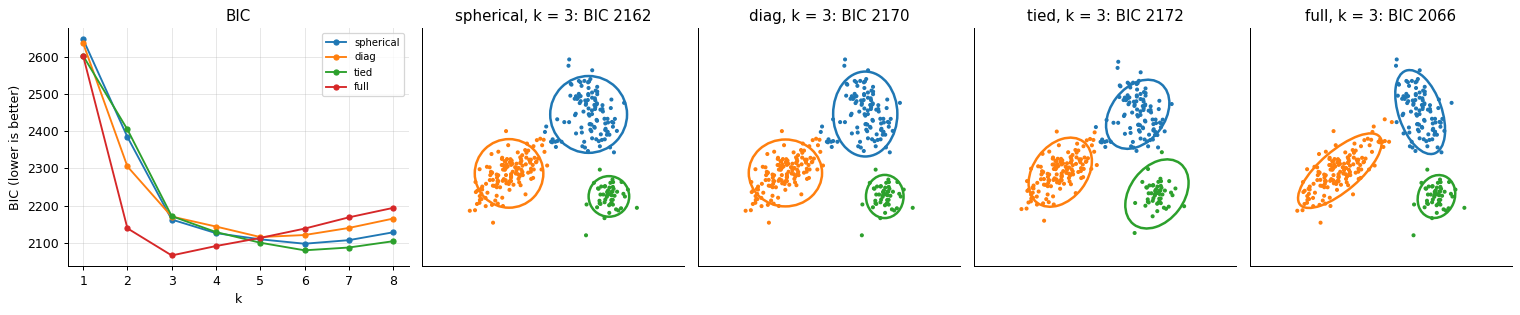

In [17]:
def n_params(cov_type, k, d):
    cov = {"full": k * d * (d + 1) / 2, "tied": d * (d + 1) / 2, "diag": k * d, "spherical": k}[cov_type]
    return int((k - 1) + k * d + cov)

cov_types = ["spherical", "diag", "tied", "full"]
bic, aic, models = {}, {}, {}
for ct in cov_types:
    bic[ct], aic[ct] = [], []
    for k in range(1, 9):
        g = GaussianMixture(k, covariance_type=ct, n_init=3, random_state=0).fit(Xg)
        ll = g.score(Xg) * len(Xg)
        p = n_params(ct, k, 2)
        b = -2 * ll + p * np.log(len(Xg))
        assert np.isclose(b, g.bic(Xg)) and np.isclose(-2 * ll + 2 * p, g.aic(Xg))
        bic[ct].append(b); aic[ct].append(-2 * ll + 2 * p); models[ct, k] = g
print("BIC and AIC by hand = GaussianMixture.bic / .aic: checked")
print("parameters for k = 3, d = 2:", {ct: n_params(ct, 3, 2) for ct in cov_types})
for ct in cov_types:
    print(f"{ct:9s}: best k by BIC = {1 + int(np.argmin(bic[ct]))} (BIC {min(bic[ct]):.1f});  by AIC = {1 + int(np.argmin(aic[ct]))}")
best_ct = min(cov_types, key=lambda c: min(bic[c]))
print("overall best:", best_ct, "with k =", 1 + int(np.argmin(bic[best_ct])))

fig, axes = plt.subplots(1, 5, figsize=(17, 3.6), gridspec_kw={"width_ratios": [1.3, 1, 1, 1, 1]})
for ct in cov_types:
    axes[0].plot(range(1, 9), bic[ct], "o-", ms=4, label=ct)
axes[0].set_xlabel("k"); axes[0].set_ylabel("BIC (lower is better)"); axes[0].legend(fontsize=8); axes[0].set_title("BIC")
for ax, ct in zip(axes[1:], cov_types):
    g = models[ct, 3]
    if ct == "full":
        covs = g.covariances_
    elif ct == "tied":
        covs = [g.covariances_] * 3
    elif ct == "diag":
        covs = [np.diag(c) for c in g.covariances_]
    else:
        covs = [np.eye(2) * c for c in g.covariances_]
    ax.scatter(Xg[:, 0], Xg[:, 1], s=5, c=label_colors(g.predict(Xg)))
    for j in range(3):
        draw_ellipse(ax, g.means_[j], covs[j], PALETTE[j])
    ax.set_title(f"{ct}, k = 3: BIC {bic[ct][2]:.0f}"); ax.set_aspect("equal", adjustable="datalim")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

**What just happened?** With full covariances BIC is lowest at $k = 3$, the true number of components, and `full` beats the other types (BIC 2066 against 2172 for `tied` and 2162 for `spherical` at $k = 3$). The restricted types cannot follow the tilted ellipses, so they compensate with more components: their BIC is lowest at $k = 6$ (spherical, tied) or $k = 5$ (diag), still above the full model with $k = 3$. AIC, with its lighter penalty, also picks $k = 3$ for full covariances, and one component more than BIC for the restricted types. A full GMM with $k = 3$ needs 17 parameters here; in high dimensions a full covariance becomes expensive and unstable, and `diag` or a PCA first (section 11) is the usual compromise.

## 7. Hierarchical clustering

**Agglomerative clustering** builds a whole hierarchy of clusterings instead of one:

1. start with $n$ clusters, one per point;
2. merge the two **closest** clusters;
3. repeat until a single cluster is left.

The result is a binary tree, the **dendrogram**; the height of each merge is the distance between the two clusters merged. Cutting the tree at a height $h$ gives the clusters that exist at that level, so one run gives every $k$ at once. "Closest clusters" needs a distance between **sets** of points, the **linkage**:

| linkage | distance between clusters $A$ and $B$ | tends to give |
|---|---|---|
| single | $\min_{a \in A, b \in B} d(a, b)$ (the closest pair) | long chains, any shape; sensitive to noise |
| complete | $\max_{a \in A, b \in B} d(a, b)$ (the farthest pair) | compact clusters of similar diameter |
| average | mean of all $d(a, b)$ | in between |
| Ward | increase of the total WCSS caused by the merge: $\Delta J = \frac{n_A n_B}{n_A + n_B}\lVert \boldsymbol{\mu}_A - \boldsymbol{\mu}_B \rVert^2$ | compact, k-means-like clusters |

Ward merges the pair that increases $J$ the least, so it is a greedy version of the k-means objective. **Cost**: the algorithm needs all pairwise distances, $O(n^2)$ memory, and $O(n^2 \log n)$ time or more: fine for 10,000 points (400 MB of distances), impossible for a million.

**Worked example** (the slides use the same numbers): six points on a line, at $0, 3, 4, 8, 14, 21$.

In [18]:
x1d = np.array([0, 3, 4, 8, 14, 21], dtype=float)
def members(Z, n, idx):
    # Points of cluster idx in a scipy linkage matrix (leaves are 0..n-1, merges are n, n+1, ...).
    if idx < n:
        return [int(x1d[int(idx)])]
    a, b = Z[int(idx) - n, :2]
    return sorted(members(Z, n, a) + members(Z, n, b))

Z1d = {}
for method in ["single", "complete", "average", "ward"]:
    Z = linkage(x1d[:, None], method=method)
    Z1d[method] = Z
    print(f"{method}:")
    for step, (a, b, h, size) in enumerate(Z):
        A, B = members(Z, 6, a), members(Z, 6, b)
        extra = ""
        if method == "ward":   # scipy reports sqrt(2 * Delta J) for Ward; we print Delta J too
            dJ = len(A) * len(B) / (len(A) + len(B)) * (np.mean(A) - np.mean(B)) ** 2
            assert np.isclose(h, np.sqrt(2 * dJ))
            extra = f"   Delta J = {dJ:.2f}"
        print(f"   merge {step + 1}: {A} + {B} at height {h:.2f}{extra}")
    print("   2 clusters:", [members(Z, 6, i) for i in Z[-1, :2]])
print("Ward heights = sqrt(2 Delta J): checked")

single:
   merge 1: [3] + [4] at height 1.00
   merge 2: [0] + [3, 4] at height 3.00
   merge 3: [8] + [0, 3, 4] at height 4.00
   merge 4: [14] + [0, 3, 4, 8] at height 6.00
   merge 5: [21] + [0, 3, 4, 8, 14] at height 7.00
   2 clusters: [[21], [0, 3, 4, 8, 14]]
complete:
   merge 1: [3] + [4] at height 1.00
   merge 2: [0] + [3, 4] at height 4.00
   merge 3: [8] + [14] at height 6.00
   merge 4: [21] + [8, 14] at height 13.00
   merge 5: [0, 3, 4] + [8, 14, 21] at height 21.00
   2 clusters: [[0, 3, 4], [8, 14, 21]]
average:
   merge 1: [3] + [4] at height 1.00
   merge 2: [0] + [3, 4] at height 3.50
   merge 3: [8] + [0, 3, 4] at height 5.67
   merge 4: [14] + [21] at height 7.00
   merge 5: [0, 3, 4, 8] + [14, 21] at height 13.75
   2 clusters: [[0, 3, 4, 8], [14, 21]]
ward:
   merge 1: [3] + [4] at height 1.00   Delta J = 0.50
   merge 2: [0] + [3, 4] at height 4.04   Delta J = 8.17
   merge 3: [8] + [14] at height 6.00   Delta J = 18.00
   merge 4: [21] + [8, 14] at height 11.5

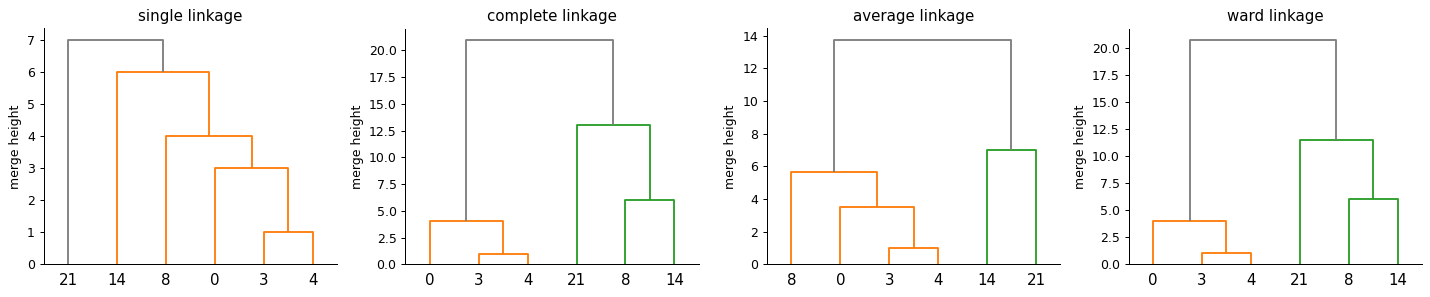

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
for ax, (method, Z) in zip(axes, Z1d.items()):
    dendrogram(Z, labels=[str(int(v)) for v in x1d], ax=ax, color_threshold=Z[-2, 2] + 1e-9, above_threshold_color="0.5")
    ax.set_title(f"{method} linkage"); ax.set_ylabel("merge height"); ax.grid(False)
plt.tight_layout(); plt.show()

**What just happened?** All four linkages first merge 3 and 4 (distance 1). Then they disagree:
- **single** adds one point at a time to the same group: 0 at distance 3, then 8 (4), then 14 (6), then 21 (7). Every new point is close to *some* member. This is the **chaining effect**: cut at 2 clusters and you get $\{0, 3, 4, 8, 14\}$ and the lonely $\{21\}$.
- **complete** joins 0 to $\{3, 4\}$ at height 4 (the farthest pair, 0–4), then 8 with 14 (6), then 21 with $\{8, 14\}$ (13): two clusters of three, $\{0, 3, 4\}$ and $\{8, 14, 21\}$.
- **average** is in between: $\{0, 3, 4, 8\}$ and $\{14, 21\}$.
- **Ward** agrees with complete here; its first increases of $J$ are 0.5, 8.17, 18 and 66.67. scipy reports the height $\sqrt{2\Delta J}$, which the `assert` checks.

The same six numbers give three different two-cluster answers. Now the dendrogram of a small two-dimensional set and how to cut it.

cutting the Ward dendrogram at height 6.0: 3 clusters, sizes [11, 9, 10]
ARI(cut, AgglomerativeClustering) = 1.000;  ARI with the 3 blobs = 0.898
merge heights (last 5): [ 2.8   3.28  5.37 13.72 14.65]


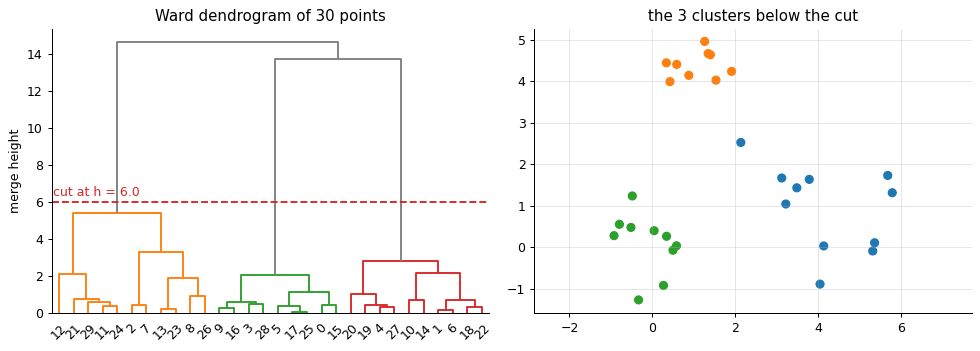

In [20]:
X30, y30 = make_blobs(n_samples=30, centers=[[0, 0], [4, 1], [1.5, 4]], cluster_std=0.8, random_state=4)
Z30 = linkage(X30, method="ward")
h_cut = 6.0
lab_cut = fcluster(Z30, t=h_cut, criterion="distance") - 1        # clusters below the cut height
lab_sk = AgglomerativeClustering(n_clusters=len(np.unique(lab_cut)), linkage="ward").fit_predict(X30)
print(f"cutting the Ward dendrogram at height {h_cut}: {len(np.unique(lab_cut))} clusters, sizes {np.bincount(lab_cut).tolist()}")
print(f"ARI(cut, AgglomerativeClustering) = {adjusted_rand_score(lab_cut, lab_sk):.3f};  ARI with the 3 blobs = {adjusted_rand_score(y30, lab_cut):.3f}")
print("merge heights (last 5):", Z30[-5:, 2].round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
dendrogram(Z30, ax=axes[0], color_threshold=h_cut, above_threshold_color="0.5")
axes[0].axhline(h_cut, color="tab:red", ls="--"); axes[0].text(1, h_cut + 0.3, f"cut at h = {h_cut}", color="tab:red")
axes[0].set_title("Ward dendrogram of 30 points"); axes[0].set_ylabel("merge height"); axes[0].grid(False)
scatter(axes[1], X30, lab_cut, f"the {len(np.unique(lab_cut))} clusters below the cut", s=40)
plt.tight_layout(); plt.show()

**Interpretation.** The last merges happen at much larger heights than the others (5.37, then 13.72 and 14.65): the big vertical gap in the dendrogram is the natural place to cut. Cutting at $h = 6$ gives the three blobs (ARI 0.898: two or three points in the overlap change side) and the same answer as `AgglomerativeClustering(n_clusters=3)`. Reading the dendrogram is the hierarchical version of the elbow.

### The chaining effect on real shapes

Two datasets: two blobs joined by a thin **bridge** of points, and the **moons**. We cut each tree at two clusters.

bridge single  : ARI  0.00, cluster sizes [214, 1]
bridge complete: ARI  1.00, cluster sizes [108, 107]
bridge average : ARI  0.87, cluster sizes [114, 101]
bridge ward    : ARI  1.00, cluster sizes [108, 107]
moons  single  : ARI  1.00, cluster sizes [250, 250]
moons  complete: ARI  0.35, cluster sizes [306, 194]
moons  average : ARI  0.75, cluster sizes [284, 216]
moons  ward    : ARI  0.63, cluster sizes [301, 199]


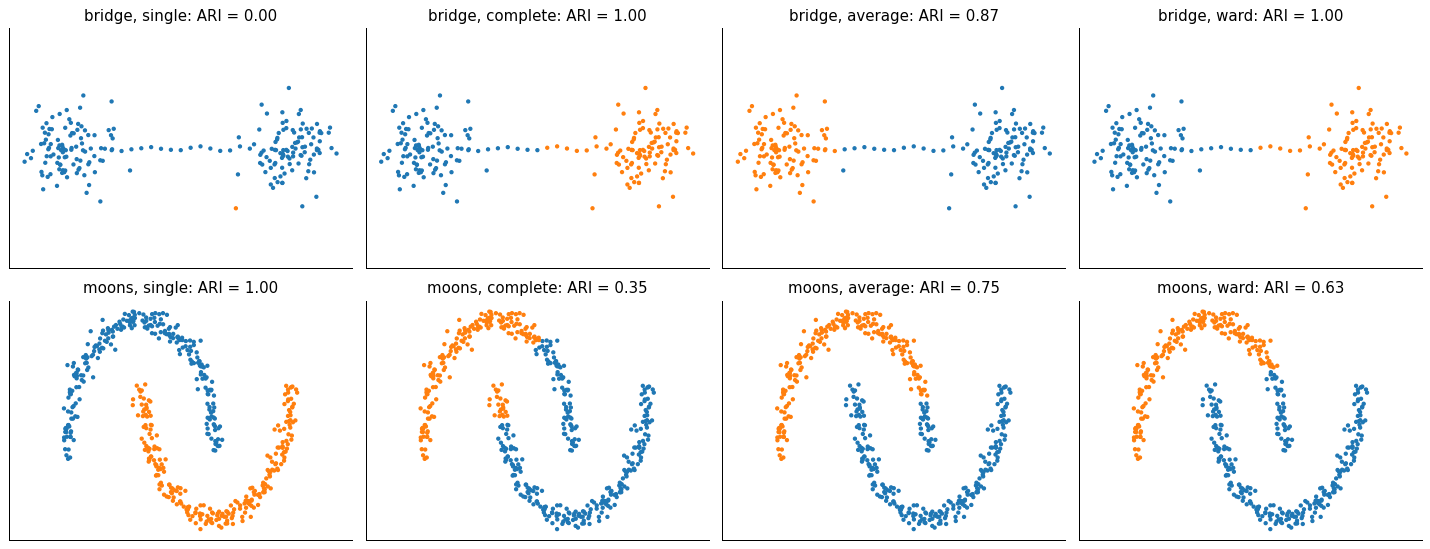

In [21]:
rng = np.random.default_rng(5)
bridge = np.c_[np.linspace(-2.2, 2.2, 15), 0.05 * rng.normal(size=15)]
X_br = np.vstack([rng.normal([-3.5, 0], 0.7, (100, 2)), rng.normal([3.5, 0], 0.7, (100, 2)), bridge])
y_br = np.r_[np.zeros(100, int), np.ones(100, int), (bridge[:, 0] > 0).astype(int)]
X_mo, y_mo = toy["moons"]

methods = ["single", "complete", "average", "ward"]
fig, axes = plt.subplots(2, 4, figsize=(16, 6.2))
for row, (Xd, yd, dname) in enumerate([(X_br, y_br, "bridge"), (X_mo, y_mo, "moons")]):
    for ax, method in zip(axes[row], methods):
        lab = AgglomerativeClustering(n_clusters=2, linkage=method).fit_predict(Xd)
        ari = adjusted_rand_score(yd, lab)
        scatter(ax, Xd, lab, f"{dname}, {method}: ARI = {ari:.2f}", s=6)
        ax.set_xticks([]); ax.set_yticks([])
        print(f"{dname:6s} {method:8s}: ARI {ari:5.2f}, cluster sizes {np.bincount(lab).tolist()}")
plt.tight_layout(); plt.show()

**Things to notice.**
- On the **bridge**, single linkage walks across the chain of close points and puts both blobs in one cluster; its second "cluster" is a single outlying point (sizes 214 and 1). Complete, average and Ward cut through the bridge and find the two blobs.
- On the **moons** it is the opposite: single linkage follows each crescent and is perfect (ARI 1.00), while complete, average and Ward cut across them, like k-means.

Single linkage is good at shapes and bad at noise; Ward is the safe default for compact clusters. As often in clustering, the right choice depends on what a cluster should be.

## 8. Density: DBSCAN from scratch and HDBSCAN

**DBSCAN** (Ester, Kriegel, Sander and Xu, 1996) defines clusters as dense regions. Two parameters: a radius $\varepsilon$ and a count `min_samples`. With $N_\varepsilon(\mathbf{x})$ the points within distance $\varepsilon$ of $\mathbf{x}$ (itself included):

- a **core point** has $\lvert N_\varepsilon(\mathbf{x}) \rvert \ge$ `min_samples`: it is inside a dense region;
- a **border point** is not core but lies within $\varepsilon$ of a core point: the edge of a dense region;
- a **noise point** is neither: it gets the label $-1$.

Two core points within $\varepsilon$ of each other are in the same cluster, and so are chains of them: the clusters are the connected components of the core points, each with the border points around it. The algorithm is a breadth-first search: take an unvisited core point, give it a new label, and spread the label to everything within $\varepsilon$, continuing only from core points.

DBSCAN finds any number of clusters of any shape and says which points are noise. It does not need $k$. It needs $\varepsilon$ and `min_samples`. Rules of thumb: `min_samples` $\approx 2d$ (at least $d + 1$); then the **k-distance plot**: for every point, the distance to its $(\text{min\_samples} - 1)$-th nearest neighbour, sorted. Points inside clusters have small values, noise has large ones, and the **knee** of the curve is a good $\varepsilon$.

In [22]:
rng = np.random.default_rng(0)
X_moons_db, y_moons_db = make_moons(300, noise=0.06, random_state=0)
noise_pts = rng.uniform([-1.5, -1.0], [2.5, 1.5], size=(30, 2))
X_db = np.vstack([X_moons_db, noise_pts])
y_db = np.r_[y_moons_db, -np.ones(30, int)]                  # -1: the 30 uniform noise points

def dbscan(X, eps, min_samples):
    # DBSCAN by breadth-first search. Returns labels (-1 = noise) and the core-point mask.
    D = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(-1))
    neigh = [np.flatnonzero(D[i] <= eps) for i in range(len(X))]     # includes the point itself
    core = np.array([len(nb) >= min_samples for nb in neigh])
    labels = np.full(len(X), -1)
    cluster = 0
    for i in range(len(X)):
        if not core[i] or labels[i] != -1:
            continue
        labels[i] = cluster
        queue = [i]
        while queue:
            p = queue.pop()
            for q in neigh[p]:
                if labels[q] == -1:
                    labels[q] = cluster
                    if core[q]:
                        queue.append(q)                     # only core points expand the cluster
        cluster += 1
    return labels, core

min_samples = 5
nn = NearestNeighbors(n_neighbors=min_samples).fit(X_db)
kdist = np.sort(nn.kneighbors(X_db)[0][:, -1])                # distance to the 4th other point (the 1st is itself)
eps = 0.15
lab_db, core_db = dbscan(X_db, eps, min_samples)
sk_db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_db)
assert np.array_equal(np.flatnonzero(core_db), np.sort(sk_db.core_sample_indices_))
assert np.array_equal(lab_db == -1, sk_db.labels_ == -1)
assert adjusted_rand_score(lab_db, sk_db.labels_) == 1.0
n_core, n_noise = core_db.sum(), (lab_db == -1).sum()
n_border = len(X_db) - n_core - n_noise
print(f"eps = {eps}, min_samples = {min_samples}: {lab_db.max() + 1} clusters, {n_core} core, {n_border} border, {n_noise} noise points")
print("same core points, same noise, ARI = 1 with scikit-learn's DBSCAN: checked")
print(f"of the 30 uniform noise points, {np.sum(lab_db[-30:] == -1)} are labelled noise;  "
      f"ARI on the 300 moon points = {adjusted_rand_score(y_moons_db, lab_db[:300]):.3f}")
for e in [0.05, 0.1, 0.15, 0.25, 0.4]:
    l, _ = dbscan(X_db, e, min_samples)
    print(f"   eps = {e:4.2f}: {l.max() + 1:2d} clusters, {np.sum(l == -1):3d} noise points")

eps = 0.15, min_samples = 5: 2 clusters, 299 core, 9 border, 22 noise points
same core points, same noise, ARI = 1 with scikit-learn's DBSCAN: checked
of the 30 uniform noise points, 20 are labelled noise;  ARI on the 300 moon points = 0.987
   eps = 0.05: 10 clusters, 272 noise points
   eps = 0.10: 10 clusters,  41 noise points
   eps = 0.15:  2 clusters,  22 noise points
   eps = 0.25:  1 clusters,  16 noise points
   eps = 0.40:  1 clusters,   9 noise points


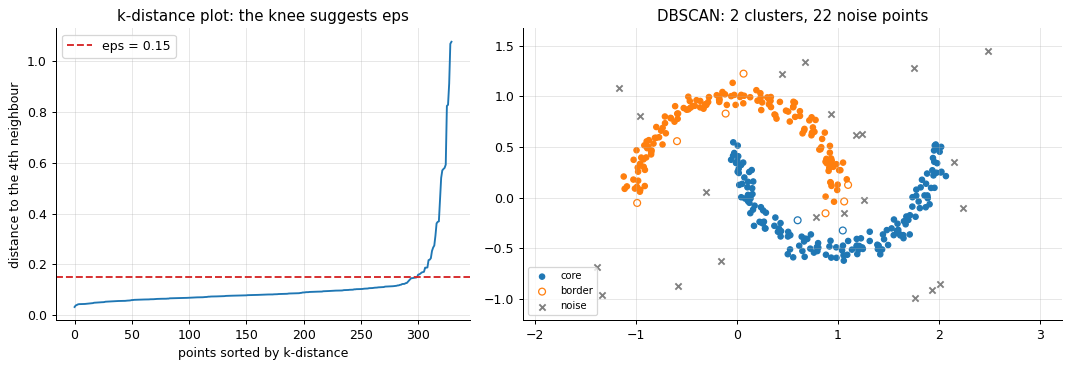

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1, 1.3]})
axes[0].plot(kdist); axes[0].axhline(eps, color="tab:red", ls="--", label=f"eps = {eps}")
axes[0].set_xlabel("points sorted by k-distance"); axes[0].set_ylabel(f"distance to the {min_samples - 1}th neighbour")
axes[0].set_title("k-distance plot: the knee suggests eps"); axes[0].legend()
border = (~core_db) & (lab_db >= 0)
axes[1].scatter(X_db[core_db, 0], X_db[core_db, 1], s=18, c=label_colors(lab_db[core_db]), label="core")
axes[1].scatter(X_db[border, 0], X_db[border, 1], s=30, facecolors="none", edgecolors=label_colors(lab_db[border]), label="border")
axes[1].scatter(X_db[lab_db == -1, 0], X_db[lab_db == -1, 1], s=25, c="0.5", marker="x", label="noise")
axes[1].set_title(f"DBSCAN: {lab_db.max() + 1} clusters, {n_noise} noise points"); axes[1].legend(fontsize=8, loc="lower left")
axes[1].set_aspect("equal", adjustable="datalim")
plt.tight_layout(); plt.show()

**What just happened?** The k-distance curve is flat (between 0.04 and 0.12) for the points inside the moons and shoots up for the scattered points; $\varepsilon = 0.15$ sits at the knee. With it DBSCAN finds the two moons, 299 core and 9 border points, and labels 22 points as noise, among them 20 of the 30 uniform ones (the others happened to fall inside a moon, where nothing can tell them apart). Our implementation and scikit-learn's agree on every core point and every noise point. The sweep shows the sensitivity to $\varepsilon$: too small and everything is noise or tiny clusters, too large and the moons merge.

### Different densities, and HDBSCAN

One $\varepsilon$ means one density threshold for the whole dataset. With two tight clusters close together and one wide cluster, there is no good value: a small $\varepsilon$ turns the wide cluster into noise, a large one merges the tight clusters.

**HDBSCAN** (Campello, Moulavi and Sander, 2013) runs DBSCAN for **every** $\varepsilon$ at once and keeps the clusters that live longest:
1. the **core distance** of $\mathbf{x}$ is the distance to its `min_samples`-th nearest point: small in dense regions;
2. the **mutual reachability distance** $d_{\text{mr}}(a, b) = \max\big(\text{core}(a), \text{core}(b), d(a, b)\big)$ pushes sparse points away from everything;
3. single linkage on $d_{\text{mr}}$ gives a tree: cutting it at height $\varepsilon$ is DBSCAN with that $\varepsilon$;
4. walking down the tree, a split counts as two real clusters only if both sides have at least `min_cluster_size` points; otherwise points just "fall out" as noise;
5. it selects the clusters that persist over the widest range of densities ($\lambda = 1/\varepsilon$), each at its own density level.

You only set `min_cluster_size`. scikit-learn has it as `sklearn.cluster.HDBSCAN` since version 1.3.

DBSCAN, eps = 0.2              : 9 clusters, 28.4 % noise, ARI = 0.762
DBSCAN, eps = 0.6              : 2 clusters,  1.2 % noise, ARI = 0.623
HDBSCAN, min_cluster_size = 15 : 3 clusters,  4.4 % noise, ARI = 0.943
the best single eps, chosen with the true labels (cheating): eps = 0.200, ARI = 0.762


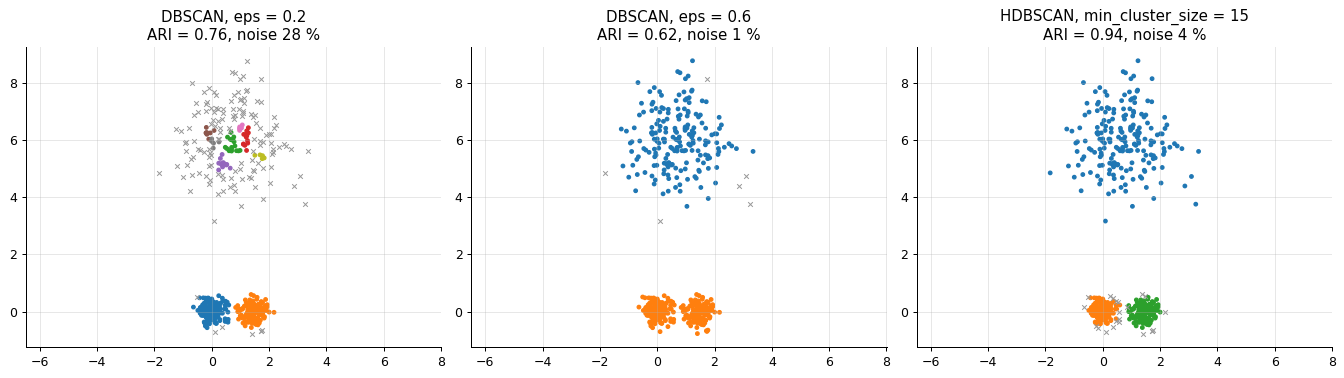

In [24]:
X_vd, y_vd = make_blobs(n_samples=[150, 150, 200], centers=[[0, 0], [1.5, 0], [0.75, 6]],
                        cluster_std=[0.25, 0.25, 1.0], random_state=0)
res_vd = {}
for e in [0.2, 0.6]:
    res_vd[f"DBSCAN, eps = {e}"] = DBSCAN(eps=e, min_samples=5).fit_predict(X_vd)
best_e = max(np.arange(0.05, 2.0, 0.025), key=lambda e: adjusted_rand_score(y_vd, DBSCAN(eps=e, min_samples=5).fit_predict(X_vd)))
hdb = HDBSCAN(min_cluster_size=15, copy=True).fit(X_vd)
res_vd["HDBSCAN, min_cluster_size = 15"] = hdb.labels_
for name, lab in res_vd.items():
    print(f"{name:31s}: {lab.max() + 1} clusters, {np.mean(lab == -1) * 100:4.1f} % noise, ARI = {adjusted_rand_score(y_vd, lab):.3f}")
print(f"the best single eps, chosen with the true labels (cheating): eps = {best_e:.3f}, "
      f"ARI = {adjusted_rand_score(y_vd, DBSCAN(eps=best_e, min_samples=5).fit_predict(X_vd)):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, (name, lab) in zip(axes, res_vd.items()):
    scatter(ax, X_vd, lab, f"{name}\nARI = {adjusted_rand_score(y_vd, lab):.2f}, noise {np.mean(lab == -1) * 100:.0f} %", s=8)
plt.tight_layout(); plt.show()

**What just happened?** With $\varepsilon = 0.2$, DBSCAN separates the two tight clusters but breaks the wide one into fragments and noise (28.4 % of all points are noise, 9 clusters). With $\varepsilon = 0.6$ the wide cluster survives but the two tight ones merge (2 clusters). The best $\varepsilon$, chosen with the true labels that we never have in practice, is the 0.2 of the left panel, with ARI 0.762. HDBSCAN, with only `min_cluster_size = 15`, finds the three clusters, each at its own density, with ARI 0.943 and 4.4 % noise. It is often the best first try for exploratory clustering with noise.

## 9. Spectral clustering from scratch

Extra 1 introduced the **graph Laplacian** $\mathbf{L} = \mathbf{D} - \mathbf{A}$ and its key identity, for a weighted graph:

$$
\mathbf{f}^\top \mathbf{L} \mathbf{f} = \sum_{(i, j) \in E} A_{ij}\,(f_i - f_j)^2 .
$$

A signal $\mathbf{f}$ with one number per node is "smooth" when $\mathbf{f}^\top\mathbf{L}\mathbf{f}$ is small. The eigenvectors of $\mathbf{L}$ with the smallest eigenvalues are the smoothest signals, and the second one, the **Fiedler vector**, split the karate club into its two factions. Spectral clustering uses exactly this on a graph built from the data.

1. **Similarity graph**: connect each point to its $m$ nearest neighbours (and symmetrise: $i$–$j$ if either is among the other's neighbours), or use all pairs with weights $A_{ij} = \exp(-\lVert \mathbf{x}_i - \mathbf{x}_j \rVert^2 / 2\sigma^2)$.
2. **Laplacian eigenvectors**: compute the $k$ eigenvectors of the Laplacian with the smallest eigenvalues and stack them as columns of an $n \times k$ matrix $\mathbf{U}$. Row $i$ of $\mathbf{U}$ is a new $k$-dimensional representation of point $i$, the **spectral embedding**.
3. **k-means** on the rows of $\mathbf{U}$.

**Why it works.** If the graph has $k$ connected components, $\mathbf{f}^\top\mathbf{L}\mathbf{f} = 0$ exactly when $\mathbf{f}$ is constant on each component (every term of the sum must vanish). So the eigenvalue 0 has multiplicity $k$, and its eigenvectors are combinations of the $k$ indicator vectors of the components: in the embedding all points of one component land on the same point, and k-means cannot fail. When the clusters are only *almost* disconnected (a few weak edges between them), the first $k$ eigenvalues are close to 0, followed by a **gap**, and the eigenvectors are almost piecewise constant. A crescent is not compact, but it is well **connected** through its neighbours, which is what the graph sees.

For two clusters, the sign of the Fiedler vector already gives the answer: it is the relaxed solution of the **minimum cut** problem (cut the graph into two parts with few edges between them, without cutting off tiny pieces). We start there, with 200 noisy moon points.

f^T L f = sum over edges of (f_i - f_j)^2: checked
graph: 200 nodes, 915 edges;  smallest eigenvalues of L: [-0.     0.008  0.041  0.058  0.155]
lambda_1 = 0.0080 is small, then a gap: lambda_2 = 0.0407 (5.1 times larger)
edges between the two moons: 1
ARI of the sign of the Fiedler vector: 1.000;   ARI of k-means on the raw points: 0.256


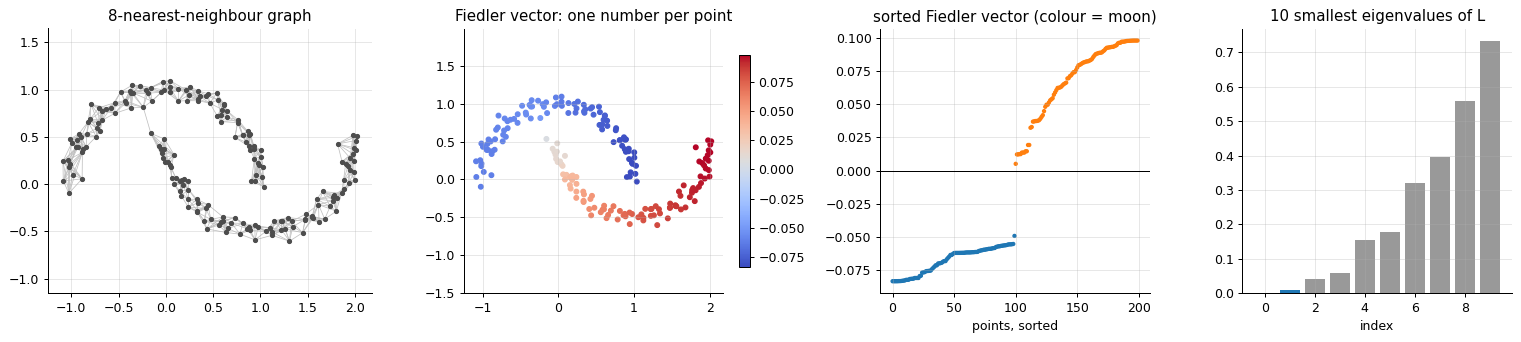

In [25]:
X_sp, y_sp = make_moons(200, noise=0.06, random_state=0)
A_sp = kneighbors_graph(X_sp, n_neighbors=8, include_self=False).toarray()
A_sp = np.maximum(A_sp, A_sp.T)                              # symmetrise: undirected graph
D_sp = np.diag(A_sp.sum(1))
L_sp = D_sp - A_sp
lam_sp, V_sp = np.linalg.eigh(L_sp)
fiedler = V_sp[:, 1]
lab_fiedler = (fiedler > 0).astype(int)
lab_km_sp = KMeans(2, n_init=10, random_state=0).fit_predict(X_sp)
f = np.random.default_rng(0).normal(size=len(X_sp))
assert np.isclose(f @ L_sp @ f, sum(A_sp[i, j] * (f[i] - f[j]) ** 2 for i, j in zip(*np.nonzero(np.triu(A_sp)))))
print("f^T L f = sum over edges of (f_i - f_j)^2: checked")
print(f"graph: {len(X_sp)} nodes, {int(A_sp.sum() / 2)} edges;  smallest eigenvalues of L: {lam_sp[:5].round(4)}")
print(f"lambda_1 = {lam_sp[1]:.4f} is small, then a gap: lambda_2 = {lam_sp[2]:.4f} ({lam_sp[2] / lam_sp[1]:.1f} times larger)")
print(f"edges between the two moons: {int(A_sp[np.ix_(y_sp == 0, y_sp == 1)].sum())}")
print(f"ARI of the sign of the Fiedler vector: {adjusted_rand_score(y_sp, lab_fiedler):.3f};   "
      f"ARI of k-means on the raw points: {adjusted_rand_score(y_sp, lab_km_sp):.3f}")

fig, axes = plt.subplots(1, 4, figsize=(17, 3.9), gridspec_kw={"width_ratios": [1.2, 1.2, 1, 1]})
for i, j in zip(*np.nonzero(np.triu(A_sp))):
    axes[0].plot(X_sp[[i, j], 0], X_sp[[i, j], 1], color="0.75", lw=0.6, zorder=1)
axes[0].scatter(X_sp[:, 0], X_sp[:, 1], s=10, c="0.3", zorder=2); axes[0].set_title("8-nearest-neighbour graph")
sc = axes[1].scatter(X_sp[:, 0], X_sp[:, 1], s=14, c=fiedler, cmap="coolwarm")
axes[1].set_title("Fiedler vector: one number per point"); plt.colorbar(sc, ax=axes[1], shrink=0.8)
order = np.argsort(fiedler)
axes[2].scatter(np.arange(len(X_sp)), fiedler[order], s=6, c=label_colors(y_sp[order]))
axes[2].axhline(0, color="k", lw=0.8); axes[2].set_title("sorted Fiedler vector (colour = moon)"); axes[2].set_xlabel("points, sorted")
axes[3].bar(range(10), lam_sp[:10], color=["tab:blue"] * 2 + ["0.6"] * 8)
axes[3].set_title("10 smallest eigenvalues of L"); axes[3].set_xlabel("index")
for ax in axes[:2]:
    ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout(); plt.show()

**What just happened?** The 8-nearest-neighbour graph links points along each crescent; only 1 of its 915 edges joins the two moons. The Laplacian has $\lambda_0 = 0$ (the constant vector, always), then $\lambda_1$ = 0.0080, then a jump to $\lambda_2$ = 0.0407: two weakly connected groups. The Fiedler vector is negative on one moon and positive on the other, almost constant inside each (the sorted plot is a clean step), and its sign recovers the moons exactly (ARI 1.000), where k-means on the raw coordinates gets ARI 0.256. It is the same vector that split the karate club in Extra 1.

Now the general algorithm with $k$ eigenvectors. We use the **normalised** Laplacian $\mathbf{L}_{\text{sym}} = \mathbf{I} - \mathbf{D}^{-1/2}\mathbf{A}\mathbf{D}^{-1/2}$ (Ng, Jordan and Weiss, 2002), which corrects for points with many neighbours, and normalise each row of $\mathbf{U}$ to length 1 before k-means. We run it on the moons and circles of section 1, with our own `kmeans` from section 3.

moons   : smallest eigenvalues [0.    0.    0.001 0.002];  ARI with the truth 1.000;  ARI(ours, scikit-learn) 1.000;  k-means on raw points 0.483
circles : smallest eigenvalues [-0.     0.     0.004  0.004];  ARI with the truth 1.000;  ARI(ours, scikit-learn) 1.000;  k-means on raw points -0.002


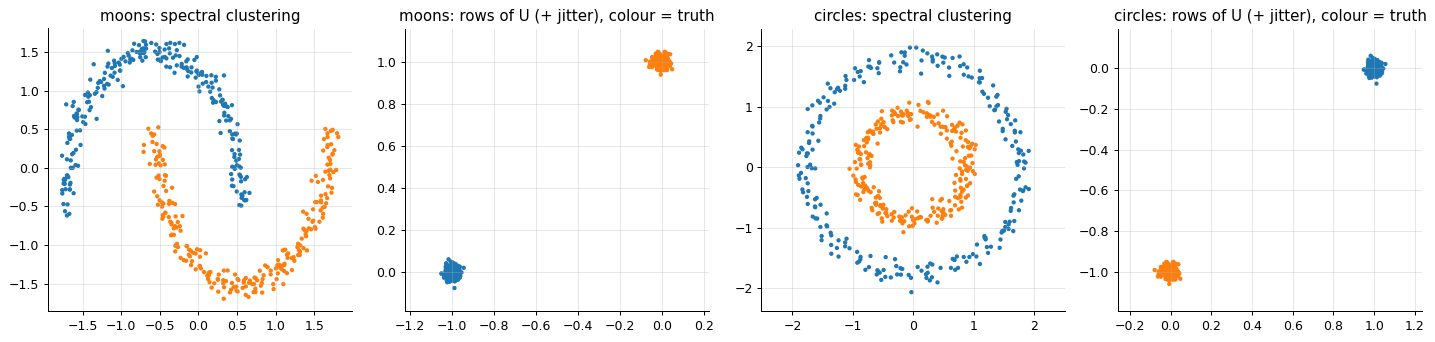

In [26]:
def spectral_clustering(X, k, n_neighbors=10, seed=0):
    # Spectral clustering (Ng-Jordan-Weiss): kNN graph, normalised Laplacian, k eigenvectors, k-means.
    A = kneighbors_graph(X, n_neighbors, include_self=False).toarray()
    A = np.maximum(A, A.T)
    d = A.sum(1)
    L_sym = np.eye(len(X)) - A / np.sqrt(np.outer(d, d))
    eigval, eigvec = np.linalg.eigh(L_sym)
    U = eigvec[:, :k]
    U = U / np.linalg.norm(U, axis=1, keepdims=True)          # each row on the unit circle (sphere)
    labels = kmeans(U, k, n_init=10, seed=seed)[0]
    return labels, eigval, U

spec_res = {}
for name in ["moons", "circles"]:
    X, y = toy[name]
    lab, eigval, U = spectral_clustering(X, 2)
    with warnings.catch_warnings():           # scikit-learn warns that the graph is disconnected: that is the point
        warnings.filterwarnings("ignore", message="Graph is not fully connected")
        sk = SpectralClustering(2, affinity="nearest_neighbors", n_neighbors=10, random_state=0).fit_predict(X)
    spec_res[name] = (lab, U)
    print(f"{name:8s}: smallest eigenvalues {eigval[:4].round(4)};  ARI with the truth {adjusted_rand_score(y, lab):.3f};  "
          f"ARI(ours, scikit-learn) {adjusted_rand_score(lab, sk):.3f};  k-means on raw points {adjusted_rand_score(y, kmeans(X, 2)[0]):.3f}")

fig, axes = plt.subplots(1, 4, figsize=(16, 3.9))
for col, name in enumerate(["moons", "circles"]):
    X, y = toy[name]
    lab, U = spec_res[name]
    scatter(axes[2 * col], X, lab, f"{name}: spectral clustering", s=6)
    jitter = np.random.default_rng(0).normal(scale=0.02, size=U.shape)
    axes[2 * col + 1].scatter(U[:, 0] + jitter[:, 0], U[:, 1] + jitter[:, 1], s=6, c=label_colors(y))
    axes[2 * col + 1].set_title(f"{name}: rows of U (+ jitter), colour = truth")
    axes[2 * col + 1].set_aspect("equal", adjustable="datalim")
plt.tight_layout(); plt.show()

**What just happened?** On both datasets the two smallest eigenvalues of $\mathbf{L}_{\text{sym}}$ are 0 (up to rounding): the 10-nearest-neighbour graph has **two connected components**, one per moon or ring, exactly the situation of the theorem. In the embedding every point of one component lands on the same spot (we add a little jitter to see them), and k-means on these rows is trivial: ARI 1 on both, the same answer as scikit-learn's `SpectralClustering`, where k-means on the raw points got 0.48 and 0.00.

**In practice.** Spectral clustering needs the eigenvectors of an $n \times n$ matrix: with a sparse kNN graph and an iterative eigensolver it scales to tens of thousands of points, not millions. Its results depend on the graph (the number of neighbours, or $\sigma$), and the eigengap $\lambda_k \ll \lambda_{k+1}$ is a useful hint for $k$.

## 10. Evaluating a clustering

**Internal indices** use only the data and the labels found. Besides the silhouette (section 4):

- **Davies–Bouldin** (lower is better): with $s_j$ the mean distance of the points of cluster $j$ to its centroid, $\text{DB} = \frac{1}{k}\sum_j \max_{l \ne j} \frac{s_j + s_l}{\lVert \boldsymbol{\mu}_j - \boldsymbol{\mu}_l \rVert}$: each cluster compared with its most similar neighbour.
- **Calinski–Harabasz** (higher is better): the ratio of the between-cluster to the within-cluster dispersion, $\text{CH} = \dfrac{\sum_j n_j \lVert \boldsymbol{\mu}_j - \bar{\mathbf{x}} \rVert^2 / (k - 1)}{\sum_j \sum_{i \in C_j} \lVert \mathbf{x}_i - \boldsymbol{\mu}_j \rVert^2 / (n - k)}$, an $F$ statistic.

All three reward compact, well-separated, round clusters, the k-means notion of a cluster. Here is what they say about the moons: k-means' straight cut against the true crescents.

In [27]:
X, y = toy["moons"]
lab_km_moons = kmeans(X, 2)[0]
print(f"{'':22s} {'silhouette (high)':>18s} {'Davies-Bouldin (low)':>21s} {'Calinski-Harabasz (high)':>25s}")
for name, lab in [("k-means' straight cut", lab_km_moons), ("the true moons", y)]:
    print(f"{name:22s} {silhouette_score(X, lab):18.3f} {davies_bouldin_score(X, lab):21.3f} {calinski_harabasz_score(X, lab):25.1f}")

                        silhouette (high)  Davies-Bouldin (low)  Calinski-Harabasz (high)
k-means' straight cut               0.496                 0.812                     690.8
the true moons                      0.385                 1.028                     429.5


**Things to notice.** All three internal indices prefer k-means' wrong answer to the true moons (silhouette 0.496 against 0.385). They measure compactness and separation in the k-means sense, so they cannot reward a connected crescent. Internal indices compare clusterings of the **same kind**; they cannot tell you which definition of "cluster" your problem needs.

### External indices: when labels exist

On benchmarks, or when a few labelled examples exist, we can compare the clustering with a reference labelling. Plain accuracy does not work: cluster numbers are arbitrary names, and a perfect clustering that calls the classes 2, 0, 1 instead of 0, 1, 2 scores 0 % accuracy. Three fixes:

- **Matched accuracy**: build the **contingency table** $n_{ab}$ = number of points with true class $a$ in cluster $b$, find the one-to-one matching of clusters to classes that maximises the matched counts (the **Hungarian algorithm**, `scipy.optimize.linear_sum_assignment`, $O(k^3)$), then compute the accuracy.
- **Adjusted Rand index (ARI)**: look at all $\binom{n}{2}$ **pairs** of points. A pair is a success if both labellings put it together, or both put it apart; the **Rand index** is the fraction of successes. It is high even for random labellings (most pairs are apart in both), so ARI subtracts its expected value under random labels with the same cluster sizes: $\text{ARI} = \frac{\text{RI} - \mathbb{E}[\text{RI}]}{\max \text{RI} - \mathbb{E}[\text{RI}]}$. ARI = 1 for identical partitions (up to renaming), about 0 for random ones, and can be negative. In terms of the contingency table, with row sums $a_r$ and column sums $b_c$:
$$
\text{ARI} = \frac{\sum_{rc}\binom{n_{rc}}{2} - \big[\sum_r \binom{a_r}{2}\sum_c \binom{b_c}{2}\big]/\binom{n}{2}}{\tfrac12\big[\sum_r \binom{a_r}{2} + \sum_c \binom{b_c}{2}\big] - \big[\sum_r \binom{a_r}{2}\sum_c \binom{b_c}{2}\big]/\binom{n}{2}} .
$$
- **Normalised mutual information (NMI)**: the mutual information between the two labellings, $I(U; V) = \sum_{rc} \frac{n_{rc}}{n}\log\frac{n\, n_{rc}}{a_r b_c}$, divided by the mean of their entropies; 1 for identical partitions, 0 for independent ones (not adjusted for chance: it grows slowly with the number of clusters).

We implement the three and check them against scikit-learn on a toy labelling of 12 points in 3 classes (the one of the slides).

In [28]:
def contingency(y, lab):
    ys, ls = np.unique(y), np.unique(lab)
    return np.array([[np.sum((y == a) & (lab == b)) for b in ls] for a in ys])

def comb2(x):
    return x * (x - 1) / 2

def ari_score(y, lab):
    N = contingency(y, lab)
    s_ij, s_a, s_b, s_n = comb2(N).sum(), comb2(N.sum(1)).sum(), comb2(N.sum(0)).sum(), comb2(N.sum())
    expected = s_a * s_b / s_n
    return (s_ij - expected) / (0.5 * (s_a + s_b) - expected)

def nmi_score(y, lab):
    N = contingency(y, lab) / len(y)
    pa, pb = N.sum(1), N.sum(0)
    nz = N > 0
    mi = (N[nz] * np.log(N[nz] / np.outer(pa, pb)[nz])).sum()
    h = lambda p: -(p[p > 0] * np.log(p[p > 0])).sum()
    return mi / (0.5 * (h(pa) + h(pb))) if mi > 0 else 0.0

def matched_accuracy(y, lab):
    N = contingency(y, lab)
    rows, cols = linear_sum_assignment(-N)                   # maximise the matched counts
    return N[rows, cols].sum() / len(y)

y12 = np.repeat([0, 1, 2], 4)
toy_preds = {"the same groups, renamed": np.repeat([2, 0, 1], 4),
             "one point in the wrong group": np.array([0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2]),
             "two groups merged": np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]),
             "one group split in two": np.array([0, 0, 3, 3, 1, 1, 1, 1, 2, 2, 2, 2]),
             "random labels": np.random.default_rng(0).integers(0, 3, 12)}
print(f"{'prediction':30s} {'raw acc':>8s} {'matched acc':>12s} {'ARI':>7s} {'NMI':>7s}")
for name, p in toy_preds.items():
    a, nmi_v, acc = ari_score(y12, p), nmi_score(y12, p), matched_accuracy(y12, p)
    assert np.isclose(a, adjusted_rand_score(y12, p)) and np.isclose(nmi_v, normalized_mutual_info_score(y12, p))
    print(f"{name:30s} {np.mean(p == y12):8.2f} {acc:12.2f} {a:7.3f} {nmi_v:7.3f}")
print("our ARI and NMI = scikit-learn's: checked")
print("random labels:", toy_preds["random labels"])
rng = np.random.default_rng(1)
rand_ari = [ari_score(np.repeat(np.arange(5), 200), rng.integers(0, 5, 1000)) for _ in range(200)]
print(f"ARI of 200 random labellings of 1000 points: mean {np.mean(rand_ari):.4f}, std {np.std(rand_ari):.4f}  (about 0)")

prediction                      raw acc  matched acc     ARI     NMI
the same groups, renamed           0.00         1.00   1.000   1.000
one point in the wrong group       0.92         0.92   0.737   0.818
two groups merged                  0.67         0.67   0.522   0.734
one group split in two             0.83         0.83   0.836   0.905
random labels                      0.25         0.67   0.165   0.324
our ARI and NMI = scikit-learn's: checked
random labels: [2 1 1 0 0 0 0 0 0 2 1 2]
ARI of 200 random labellings of 1000 points: mean 0.0001, std 0.0015  (about 0)


**What just happened?** Renaming the groups gives a raw accuracy of 0 but a matched accuracy, ARI and NMI of 1: the partition is identical. One misplaced point costs 1/12 = 0.08 of matched accuracy and brings ARI to 0.737. Merging two groups is punished harder by ARI (0.522) than splitting one (0.836); NMI is milder on both (0.734 and 0.905). The random labelling still has a matched accuracy of 0.67, because the matching picks the best of $3! = 6$ renamings, while its ARI is 0.165: ARI is the honest number. Over 200 random labellings of 1,000 points, ARI averages 0.0001.

### Stability

Without labels, a useful check is **stability**: a real structure should come back when the data change a little. We draw pairs of random subsamples (80 % of the points each), cluster each with k-means, and compute the ARI between the two labellings on the points they share. We repeat it 20 times for each $k$ on the four blobs `X4`.

k = 2: stability (mean ARI between subsamples) = 0.931 +/- 0.208
k = 3: stability (mean ARI between subsamples) = 0.952 +/- 0.144
k = 4: stability (mean ARI between subsamples) = 0.981 +/- 0.081
k = 5: stability (mean ARI between subsamples) = 0.851 +/- 0.052


k = 6: stability (mean ARI between subsamples) = 0.749 +/- 0.060
k = 7: stability (mean ARI between subsamples) = 0.717 +/- 0.121


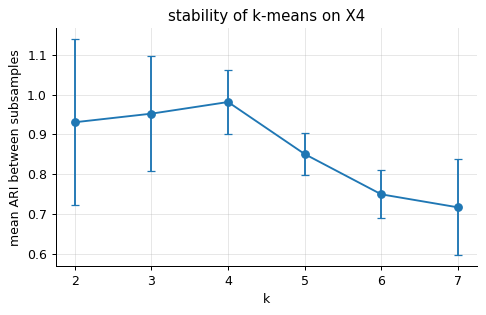

In [29]:
rng = np.random.default_rng(0)
stab = {}
for k in range(2, 8):
    scores = []
    for rep in range(20):
        i1 = rng.choice(len(X4), int(0.8 * len(X4)), replace=False)
        i2 = rng.choice(len(X4), int(0.8 * len(X4)), replace=False)
        common = np.intersect1d(i1, i2)
        m1 = KMeans(k, n_init=1, random_state=int(rng.integers(1e9))).fit(X4[i1])
        m2 = KMeans(k, n_init=1, random_state=int(rng.integers(1e9))).fit(X4[i2])
        scores.append(adjusted_rand_score(m1.predict(X4[common]), m2.predict(X4[common])))
    stab[k] = (np.mean(scores), np.std(scores))
    print(f"k = {k}: stability (mean ARI between subsamples) = {stab[k][0]:.3f} +/- {stab[k][1]:.3f}")

fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.errorbar(list(stab), [v[0] for v in stab.values()], yerr=[v[1] for v in stab.values()], fmt="o-", capsize=3)
ax.set_xlabel("k"); ax.set_ylabel("mean ARI between subsamples"); ax.set_title("stability of k-means on X4")
plt.tight_layout(); plt.show()

**Interpretation.** $k = 4$ is the most stable: the clustering comes back almost identically from one subsample to another (mean ARI 0.981). $k = 2$ and $k = 3$ are less stable (0.931 and 0.952, with large spreads): with four blobs there are several almost equally good ways to make two or three groups, and different subsamples pick different ones. From $k = 5$ on, an extra centroid splits one blob in an arbitrary place that changes every time (0.851, then 0.749 and 0.717). Stability does not prove a clustering is meaningful (k-means on the moons is stable and wrong), but instability shows that part of it is noise.

### No free lunch: every algorithm on every dataset

The classic picture: rows are the six datasets of section 1, columns are seven algorithms, each with reasonable parameters (the same as scikit-learn's comparison example where they apply). The number in each panel is the ARI with the generating groups (for "no structure", the number of clusters found).

42 clusterings in 0.2 s
         k-means  GMM (full)  Ward  single linkage  DBSCAN  HDBSCAN  spectral
circles    -0.00       -0.00 -0.00            1.00    1.00     1.00      1.00
moons       0.48        0.51  0.63            1.00    1.00     1.00      1.00
varied      0.73        0.95  0.85            0.00    0.79     0.81      0.80
aniso       0.57        1.00  0.62            0.57    0.80     0.98      0.98
blobs       0.97        0.96  0.96            0.00    0.55     0.56      0.96
clusters found on 'no structure': {'k-means': 3, 'GMM (full)': 3, 'Ward': 3, 'single linkage': 3, 'DBSCAN': 1, 'HDBSCAN': 1, 'spectral': 3}


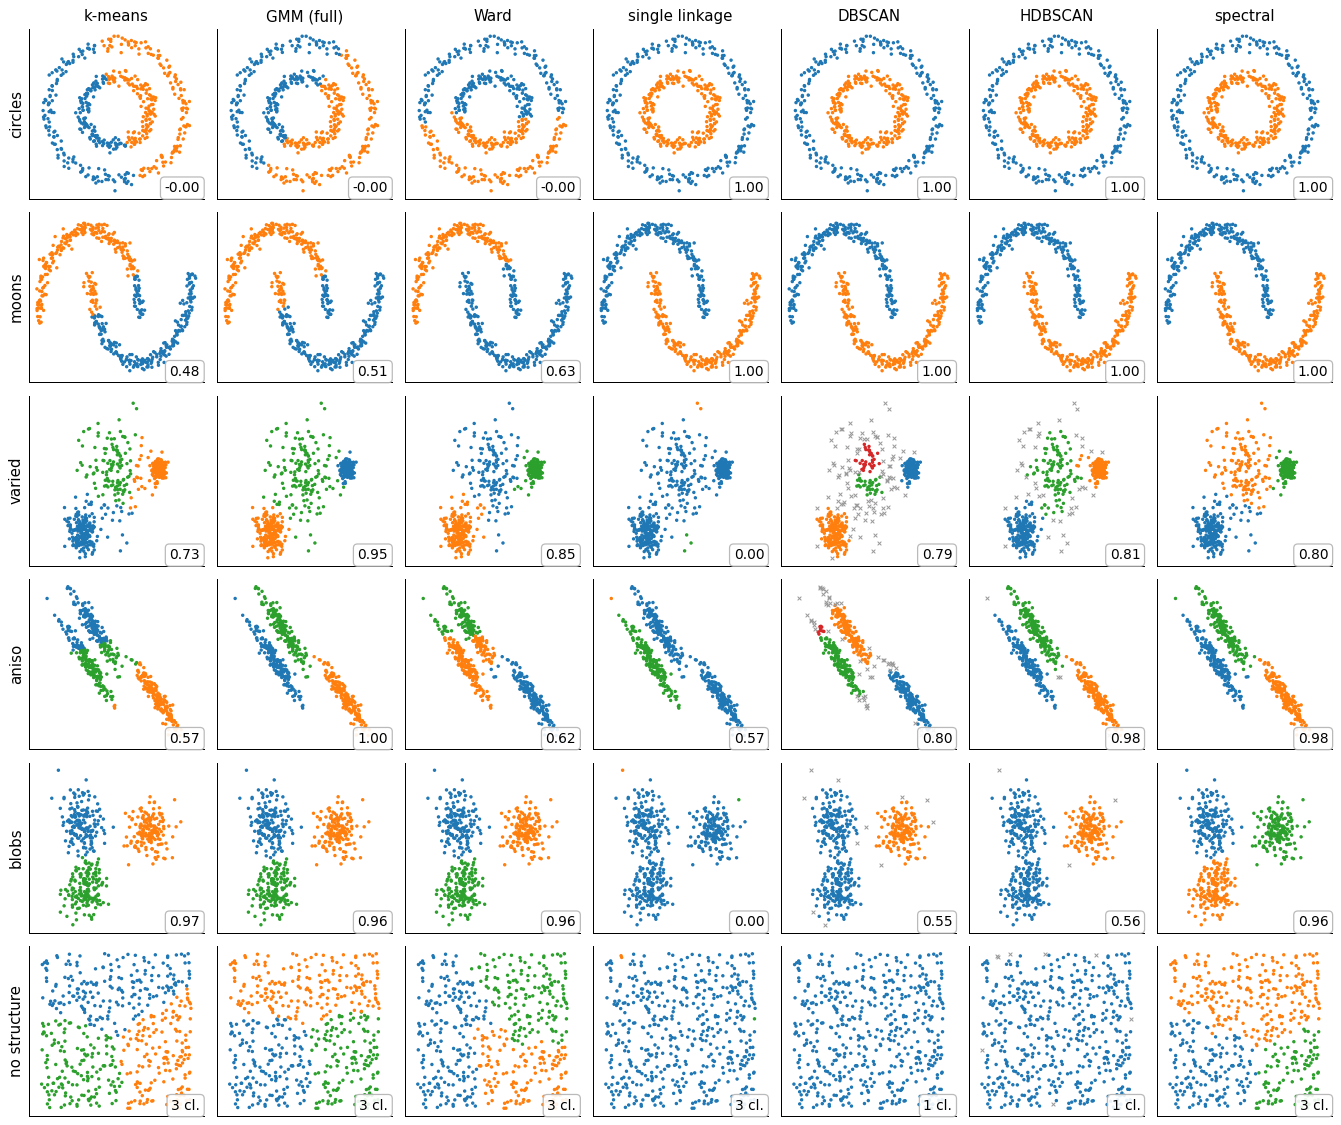

In [30]:
eps_toy = {"varied": 0.18, "aniso": 0.15}            # DBSCAN radius per dataset, as in scikit-learn's example
algos = {
    "k-means": lambda X, k, d: KMeans(k, n_init=10, random_state=0).fit_predict(X),
    "GMM (full)": lambda X, k, d: GaussianMixture(k, covariance_type="full", random_state=0).fit(X).predict(X),
    "Ward": lambda X, k, d: AgglomerativeClustering(k, linkage="ward").fit_predict(X),
    "single linkage": lambda X, k, d: AgglomerativeClustering(k, linkage="single").fit_predict(X),
    "DBSCAN": lambda X, k, d: DBSCAN(eps=eps_toy.get(d, 0.3), min_samples=7).fit_predict(X),
    "HDBSCAN": lambda X, k, d: HDBSCAN(min_samples=3, min_cluster_size=15, allow_single_cluster=True, copy=True).fit_predict(X),
    "spectral": lambda X, k, d: SpectralClustering(k, affinity="nearest_neighbors", n_neighbors=10, random_state=0).fit_predict(X),
}
grid_labels, grid_ari = {}, {}
t0 = time.time()
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Graph is not fully connected")      # spectral on 'no structure'
    for dname, (X, y) in toy.items():
        for aname, f in algos.items():
            lab = f(X, k_toy[dname], dname)
            grid_labels[dname, aname] = lab
            grid_ari[dname, aname] = np.nan if y is None else adjusted_rand_score(y, lab)
print(f"42 clusterings in {time.time() - t0:.1f} s")
table = pd.DataFrame({a: [grid_ari[d, a] for d in toy] for a in algos}, index=list(toy)).round(2)
print(table.drop(index="no structure").to_string())
print("clusters found on 'no structure':", {a: int(len(set(grid_labels['no structure', a]) - {-1})) for a in algos})

fig, axes = plt.subplots(6, 7, figsize=(15, 12.6))
for r, (dname, (X, y)) in enumerate(toy.items()):
    for c, aname in enumerate(algos):
        ax = axes[r, c]
        lab = grid_labels[dname, aname]
        scatter(ax, X, lab, "", s=3)
        txt = f"{grid_ari[dname, aname]:.2f}" if y is not None else f"{len(set(lab) - {-1})} cl."
        ax.text(0.98, 0.02, txt, transform=ax.transAxes, ha="right", va="bottom", fontsize=11,
                bbox=dict(boxstyle="round", fc="w", ec="0.7", alpha=0.9))
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if r == 0:
            ax.set_title(aname, fontsize=12)
        if c == 0:
            ax.set_ylabel(dname, fontsize=12)
plt.tight_layout(); plt.show()

**What just happened?** No column wins every row.
- **k-means** and **Ward** are perfect on the blobs and fail on every non-convex shape.
- The **GMM** fixes the *aniso* and *varied* sets (ARI 1.00 and 0.95), thanks to its full covariances, and still fails on the moons and circles.
- **Single linkage** and **spectral clustering** follow the moons and circles perfectly. Single linkage chains everything on the *varied* set (0.00); spectral clustering handles the blobs too.
- **DBSCAN** and **HDBSCAN** follow the shapes and leave the outskirts as noise. HDBSCAN adapts to the *aniso* set (0.98 against 0.80 for DBSCAN's single $\varepsilon$), but both merge the two blobs that touch (0.55 and 0.56): for a density method, two blobs joined by dense points are one cluster.
- On **no structure** every method with a fixed $k$ returns 3 clusters of uniform noise, and they look convincing. DBSCAN and HDBSCAN answer "one cluster". A method with a fixed $k$ always answers $k$: check that the clusters are real (stability, a null model, domain sense) before interpreting them.

## 11. A real dataset: handwritten digits

`load_digits` (bundled with scikit-learn) has 1,797 images of handwritten digits, $8 \times 8$ pixels with grey levels 0 to 16, so $d = 64$. The labels exist but we pretend they do not, and use them only to score the clusterings with ARI, NMI and the matched accuracy. All pixels share the same units, so we do not standardise (standardising would blow up the nearly constant border pixels). Representations:

- the **raw pixels** (64 dimensions);
- **PCA** to 30 dimensions (96 % of the variance): cheaper, less noise, and it makes full-covariance GMMs feasible;
- **t-SNE** to 2 dimensions: a non-linear map for visualisation that keeps each point's **neighbours** close.

In [31]:
Xd, yd = load_digits(return_X_y=True)
pca = PCA(30, random_state=0).fit(Xd)
Zd = pca.transform(Xd)
print(f"digits: {Xd.shape}, classes {np.bincount(yd).tolist()};  PCA(30) keeps {pca.explained_variance_ratio_.sum():.1%} of the variance")
t0 = time.time()
Ed = TSNE(2, random_state=0, init="pca").fit_transform(Xd)
print(f"t-SNE: {time.time() - t0:.1f} s")

digit_runs = {
    "k-means, raw pixels": lambda: KMeans(10, n_init=10, random_state=0).fit_predict(Xd),
    "k-means, PCA 30": lambda: KMeans(10, n_init=10, random_state=0).fit_predict(Zd),
    "GMM (full), PCA 30": lambda: GaussianMixture(10, covariance_type="full", n_init=3, random_state=0).fit(Zd).predict(Zd),
    "Ward, raw pixels": lambda: AgglomerativeClustering(10, linkage="ward").fit_predict(Xd),
    "spectral (10-NN graph)": lambda: SpectralClustering(10, affinity="nearest_neighbors", n_neighbors=10, random_state=0).fit_predict(Xd),
    "HDBSCAN, raw pixels": lambda: HDBSCAN(min_cluster_size=20, copy=True).fit_predict(Xd),
    "k-means on the t-SNE map": lambda: KMeans(10, n_init=10, random_state=0).fit_predict(Ed),
}
digit_res = {}
print(f"\n{'method':26s} {'ARI':>6s} {'NMI':>6s} {'matched acc':>12s} {'clusters':>9s} {'noise':>6s}")
for name, run in digit_runs.items():
    lab = run()
    digit_res[name] = lab
    lab_acc = np.where(lab < 0, lab.max() + 1, lab)              # noise as one extra cluster for the accuracy
    print(f"{name:26s} {adjusted_rand_score(yd, lab):6.3f} {normalized_mutual_info_score(yd, lab):6.3f} "
          f"{matched_accuracy(yd, lab_acc):12.3f} {len(set(lab) - {-1}):9d} {np.mean(lab < 0):6.1%}")

digits: (1797, 64), classes [178, 182, 177, 183, 181, 182, 181, 179, 174, 180];  PCA(30) keeps 95.9% of the variance


t-SNE: 2.8 s

method                        ARI    NMI  matched acc  clusters  noise
k-means, raw pixels         0.666  0.742        0.792        10   0.0%
k-means, PCA 30             0.666  0.740        0.792        10   0.0%


GMM (full), PCA 30          0.836  0.864        0.920        10   0.0%
Ward, raw pixels            0.794  0.868        0.840        10   0.0%
spectral (10-NN graph)      0.756  0.854        0.808        10   0.0%


HDBSCAN, raw pixels         0.206  0.572        0.546         8  50.8%
k-means on the t-SNE map    0.883  0.908        0.941        10   0.0%


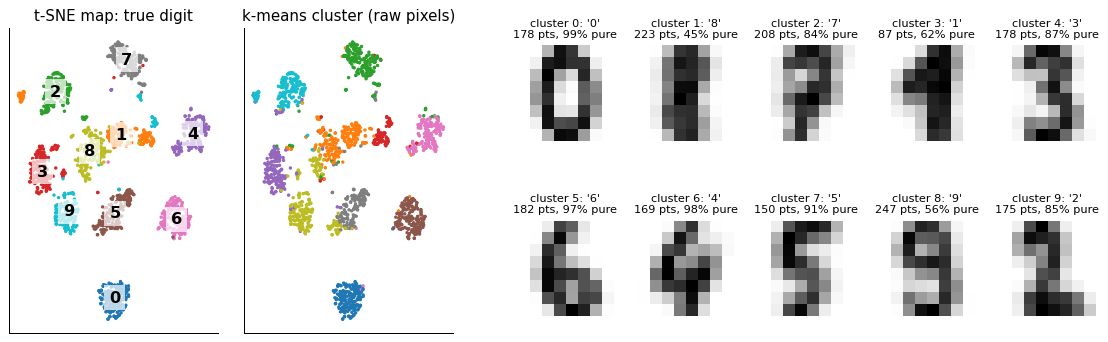

k-means clusters matched to digits (Hungarian): {0: 0, 1: 8, 2: 7, 3: 1, 4: 3, 5: 6, 6: 4, 7: 5, 8: 9, 9: 2}
contingency table (rows = true digit, columns = cluster):
 [[176   0   0   0   0   0   2   0   0   0]
 [  0 100   0  54   1   2   0   1   0  24]
 [  1   8   3   2  13   0   0   0   2 148]
 [  0   7   7   0 154   0   0   2  13   0]
 [  0   2  11   3   0   0 165   0   0   0]
 [  0   0   0   0   2   1   2 136  41   0]
 [  1   3   0   0   0 177   0   0   0   0]
 [  0   2 174   2   0   0   0   1   0   0]
 [  0 100   5   6   2   2   0   4  52   3]
 [  0   1   8  20   6   0   0   6 139   0]]


In [32]:
lab_kd = digit_res["k-means, raw pixels"]
km_d = KMeans(10, n_init=10, random_state=0).fit(Xd)
assert np.array_equal(km_d.labels_, lab_kd)
N_d = contingency(yd, lab_kd)
rows_d, cols_d = linear_sum_assignment(-N_d)
match = dict(zip(cols_d, rows_d))                                # cluster -> digit
fig = plt.figure(figsize=(16, 4.4))
gs = fig.add_gridspec(2, 9, width_ratios=[2.2, 2.2, 0.15] + [1] * 5 + [0.05], hspace=0.35, wspace=0.25)
ax0, ax1 = fig.add_subplot(gs[:, 0]), fig.add_subplot(gs[:, 1])
ax0.scatter(Ed[:, 0], Ed[:, 1], s=3, c=label_colors(yd)); ax0.set_title("t-SNE map: true digit")
for dgt in range(10):
    cx, cy = np.median(Ed[yd == dgt], axis=0)
    ax0.text(cx, cy, str(dgt), fontsize=13, weight="bold", ha="center", va="center", bbox=dict(fc="w", alpha=0.7, ec="none"))
ax1.scatter(Ed[:, 0], Ed[:, 1], s=3, c=label_colors(lab_kd)); ax1.set_title("k-means cluster (raw pixels)")
for ax in (ax0, ax1):
    ax.set_xticks([]); ax.set_yticks([])
for j in range(10):
    ax = fig.add_subplot(gs[j // 5, 3 + j % 5])
    ax.imshow(km_d.cluster_centers_[j].reshape(8, 8), cmap="gray_r")
    purity = N_d[:, j].max() / N_d[:, j].sum()
    ax.set_title(f"cluster {j}: '{match[j]}'\n{N_d[:, j].sum()} pts, {purity:.0%} pure", fontsize=9)
    ax.axis("off")
plt.show()
print("k-means clusters matched to digits (Hungarian):", {int(j): int(match[j]) for j in range(10)})
print("contingency table (rows = true digit, columns = cluster):\n", N_d)

**What just happened?** The table compares representations and definitions of "cluster" on real data.
- **k-means** reaches ARI 0.666 (matched accuracy 0.792) on the raw pixels and the same on 30 PCA components: PCA kept the structure and made it 2 times cheaper.
- **Ward** (0.794) and **spectral clustering** (0.756) do better: digits are not round blobs.
- The **full GMM on PCA 30** is the best method in the original space (ARI 0.836, matched accuracy 0.920): each digit is an elongated cloud that a covariance matrix describes well.
- **HDBSCAN** in 64 dimensions labels 50.8 % of the points as noise: densities are hard to estimate in high dimension.
- **k-means on the t-SNE map** scores highest (ARI 0.883). Read the warning below before using it.

The **centroids are interpretable**: each one is an average digit, so a cluster can be read by looking at its centroid. Most clusters are pure (0, 4 and 6 at 97 % or more); the mixed ones are cluster 1, with 100 ones and 100 eights, and cluster 8, with 139 nines, 52 eights and 41 fives (see the contingency table). Similar-looking digits share a cluster, and the ones are split over two clusters. This is exactly how one labels a dataset quickly: cluster, look at the centroids and a few members, name the clusters, fix the mixed ones by hand.

### Why t-SNE (and UMAP) maps are for looking, not for clustering

t-SNE places points in 2-D so that each point keeps roughly the same **neighbours** as in the original space. It does **not** preserve distances between groups, the sizes of groups, or densities: the size of a blob and the gap between two blobs in a t-SNE plot mean little, and they change with the `perplexity` parameter and the seed. It has no `transform` for new points. And it can create structure from nothing: below, 500 points from a **single** 10-dimensional Gaussian, mapped with a small perplexity, and HDBSCAN on the map.

perplexity  2: HDBSCAN on the t-SNE map finds 17 clusters (30% noise);  silhouette of k-means(5): on the map 0.36, in the original space 0.07


perplexity 30: HDBSCAN on the t-SNE map finds 2 clusters (25% noise);  silhouette of k-means(5): on the map 0.34, in the original space 0.07
HDBSCAN in the original 10-D space: 0 clusters, 100% noise


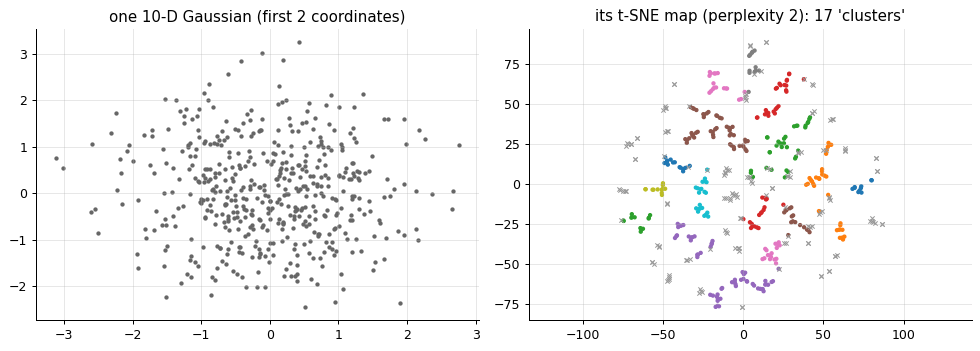

In [33]:
G_noise = np.random.default_rng(0).normal(size=(500, 10))           # one round Gaussian: no clusters at all
for perp in [2, 30]:
    E_noise = TSNE(2, perplexity=perp, random_state=0, init="pca").fit_transform(G_noise)
    lab_noise = HDBSCAN(min_cluster_size=10, copy=True).fit_predict(E_noise)
    print(f"perplexity {perp:2d}: HDBSCAN on the t-SNE map finds {lab_noise.max() + 1} clusters "
          f"({np.mean(lab_noise < 0):.0%} noise);  silhouette of k-means(5): on the map "
          f"{silhouette_score(E_noise, KMeans(5, n_init=10, random_state=0).fit_predict(E_noise)):.2f}, "
          f"in the original space {silhouette_score(G_noise, KMeans(5, n_init=10, random_state=0).fit_predict(G_noise)):.2f}")
    if perp == 2:
        E_noise2, lab_noise2 = E_noise, lab_noise
lab_raw_noise = HDBSCAN(min_cluster_size=10, copy=True).fit_predict(G_noise)
print(f"HDBSCAN in the original 10-D space: {lab_raw_noise.max() + 1} clusters, {np.mean(lab_raw_noise < 0):.0%} noise")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(G_noise[:, 0], G_noise[:, 1], s=6, c="0.4"); axes[0].set_title("one 10-D Gaussian (first 2 coordinates)")
scatter(axes[1], E_noise2, lab_noise2, f"its t-SNE map (perplexity 2): {lab_noise2.max() + 1} 'clusters'", s=6)
plt.tight_layout(); plt.show()

**What just happened?** The data have no clusters, yet with perplexity 2 the t-SNE map shows clumps and HDBSCAN on the map finds 17 "clusters"; even with the default perplexity 30 it finds 2. The silhouette of k-means with 5 clusters is 0.36 on the map against 0.07 in the original space. In the original space HDBSCAN correctly finds no cluster at all (every point is noise).

**Rule.** Use t-SNE or UMAP to **look** at high-dimensional data and at clusters found elsewhere. If you cluster on such a map (UMAP + HDBSCAN is popular, and it worked well on the digits), check that the clusters survive other seeds and perplexities, and that they make sense in the original features. For a reduction that keeps distances, use PCA.

## 12. Practice: mixed data, the Gower distance and cluster profiles

Real tables mix numbers and categories: age and premium, but also region and vehicle type. The Euclidean distance needs numbers; one-hot encoding the categories works but their weight then depends on the scaling of everything else. The **Gower distance** (Gower, 1971) averages one dissimilarity per feature, each in $[0, 1]$:

$$
d_{\text{Gower}}(\mathbf{x}, \mathbf{x}') = \frac{1}{p}\sum_{f=1}^{p} \delta_f, \qquad
\delta_f = \begin{cases} \lvert x_f - x'_f \rvert / R_f & \text{numeric feature with range } R_f \\ \mathbb{1}[x_f \ne x'_f] & \text{categorical feature.} \end{cases}
$$

Any method that accepts a precomputed distance matrix can use it: hierarchical clustering (average or complete linkage), DBSCAN, HDBSCAN. k-means cannot, because the mean of "urban" and "rural" is not defined. Its cousin **k-medoids** can: the centre of each cluster must be one of the data points, the **medoid**, the member with the smallest total distance to the others. Lloyd's two steps become: assign every point to the nearest medoid; in every cluster, make the medoid the member that minimises the sum of distances to its cluster mates. Like k-means, no step increases the total distance. (For categorical data **k-modes** replaces means by modes, and **k-prototypes** combines k-means on the numbers with k-modes on the categories.)

A synthetic portfolio of 300 policyholders from three hidden segments: young urban drivers, families, and rural seniors.

In [34]:
rng = np.random.default_rng(7)
seg_sizes = [100, 120, 80]
P_REGION = [[0.85, 0.1, 0.05], [0.15, 0.75, 0.1], [0.05, 0.15, 0.8]]       # urban, suburban, rural
P_VEHICLE = [[0.3, 0.05, 0.65], [0.25, 0.7, 0.05], [0.85, 0.1, 0.05]]      # car, van, motorbike
pol = pd.DataFrame({
    "age": np.r_[rng.normal(24, 3, 100), rng.normal(42, 6, 120), rng.normal(68, 6, 80)].round(),
    "premium": np.r_[rng.normal(1100, 200, 100), rng.normal(750, 150, 120), rng.normal(500, 120, 80)].round(),
    "claims": np.r_[rng.poisson(1.2, 100), rng.poisson(0.5, 120), rng.poisson(0.3, 80)],
    "region": np.concatenate([rng.choice(["urban", "suburban", "rural"], n, p=p) for n, p in zip(seg_sizes, P_REGION)]),
    "vehicle": np.concatenate([rng.choice(["car", "van", "motorbike"], n, p=p) for n, p in zip(seg_sizes, P_VEHICLE)]),
})
segment = np.repeat([0, 1, 2], seg_sizes)
num_cols, cat_cols = ["age", "premium", "claims"], ["region", "vehicle"]
print(pol.head().to_string())

def gower_matrix(df, num_cols, cat_cols):
    # Gower distance between all rows: range-scaled absolute differences and 0/1 mismatches, averaged.
    parts = []
    for c in num_cols:
        v = df[c].to_numpy(float)
        parts.append(np.abs(v[:, None] - v[None, :]) / (v.max() - v.min()))
    for c in cat_cols:
        v = df[c].to_numpy()
        parts.append((v[:, None] != v[None, :]).astype(float))
    return np.mean(parts, axis=0)

G = gower_matrix(pol, num_cols, cat_cols)
i, j = 0, 150
by_hand = [abs(pol.loc[i, c] - pol.loc[j, c]) / (pol[c].max() - pol[c].min()) for c in num_cols] + \
          [float(pol.loc[i, c] != pol.loc[j, c]) for c in cat_cols]
print(f"\nrows {i} and {j}: per-feature dissimilarities {np.round(by_hand, 3)} -> Gower = {np.mean(by_hand):.3f}")
assert np.isclose(G[i, j], np.mean(by_hand)) and np.allclose(G, G.T) and np.allclose(np.diag(G), 0)
print("Gower matrix: symmetric, zero diagonal, entry (0, 150) = hand computation: checked")

def kmedoids(D, k, n_init=10, seed=0, max_iter=100):
    # k-medoids on a distance matrix D: alternate nearest-medoid assignment and medoid update (best of n_init).
    rng, best = np.random.default_rng(seed), None
    for _ in range(n_init):
        med = [rng.integers(len(D))]
        for _ in range(k - 1):                                     # k-means++-style seeding on D
            d2 = D[:, med].min(1) ** 2
            med.append(rng.choice(len(D), p=d2 / d2.sum()))
        med = np.array(med)
        for _ in range(max_iter):
            lab = D[:, med].argmin(1)
            new = np.array([np.flatnonzero(lab == j)[D[np.ix_(lab == j, lab == j)].sum(1).argmin()] for j in range(k)])
            if np.array_equal(new, med):
                break
            med = new
        lab = D[:, med].argmin(1)
        cost = D[np.arange(len(D)), med[lab]].sum()
        if best is None or cost < best[2]:
            best = (lab, med, cost)
    return best

lab_gower, medoids, cost_gower = kmedoids(G, 3)
X_onehot = np.c_[StandardScaler().fit_transform(pol[num_cols]), pd.get_dummies(pol[cat_cols]).to_numpy(float)]
lab_onehot = KMeans(3, n_init=10, random_state=0).fit_predict(X_onehot)
lab_numonly = KMeans(3, n_init=10, random_state=0).fit_predict(StandardScaler().fit_transform(pol[num_cols]))
print(f"\nARI with the hidden segments: Gower + k-medoids {adjusted_rand_score(segment, lab_gower):.3f};  "
      f"one-hot + standardised + k-means {adjusted_rand_score(segment, lab_onehot):.3f};  numbers only + k-means "
      f"{adjusted_rand_score(segment, lab_numonly):.3f}")

    age  premium  claims    region    vehicle
0  24.0   1402.0       2     rural        car
1  25.0   1211.0       1     urban        car
2  23.0   1088.0       0  suburban  motorbike
3  21.0    984.0       2     urban        car
4  23.0    973.0       0     urban  motorbike

rows 0 and 150: per-feature dissimilarities [0.219 0.498 0.667 1.    0.   ] -> Gower = 0.477
Gower matrix: symmetric, zero diagonal, entry (0, 150) = hand computation: checked

ARI with the hidden segments: Gower + k-medoids 0.735;  one-hot + standardised + k-means 0.839;  numbers only + k-means 0.605


         size    age  premium  claims          region          vehicle
cluster                                                               
0          94  62.51   523.11    0.30     rural (84%)        car (94%)
1          96  24.59  1078.33    1.15     urban (88%)  motorbike (67%)
2         110  40.47   740.47    0.44  suburban (80%)        van (78%)

the medoids: one real policyholder per cluster
      age  premium  claims    region    vehicle
269  67.0    528.0       0     rural        car
8    23.0   1031.0       1     urban  motorbike
147  41.0    716.0       0  suburban        van


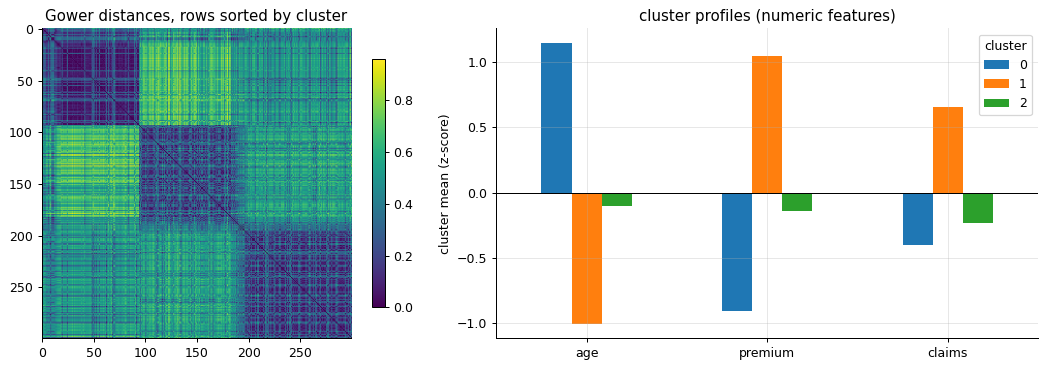

In [35]:
pol["cluster"] = lab_gower
profile = pol.groupby("cluster").agg(size=("age", "size"), age=("age", "mean"), premium=("premium", "mean"),
                                     claims=("claims", "mean"))
for c in cat_cols:
    shares = pd.crosstab(pol["cluster"], pol[c], normalize="index")
    profile[c] = [f"{shares.loc[k].idxmax()} ({shares.loc[k].max():.0%})" for k in profile.index]
print(profile.round(2).to_string())
print("\nthe medoids: one real policyholder per cluster")
print(pol.loc[medoids, num_cols + cat_cols].to_string())

order = np.argsort(lab_gower, kind="stable")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1, 1.3]})
im = axes[0].imshow(G[np.ix_(order, order)], cmap="viridis"); axes[0].grid(False)
axes[0].set_title("Gower distances, rows sorted by cluster"); plt.colorbar(im, ax=axes[0], shrink=0.8)
z = (pol.groupby("cluster")[num_cols].mean() - pol[num_cols].mean()) / pol[num_cols].std()
z.T.plot.bar(ax=axes[1], color=PALETTE[:3], rot=0)
axes[1].axhline(0, color="k", lw=0.8); axes[1].set_ylabel("cluster mean (z-score)")
axes[1].set_title("cluster profiles (numeric features)"); axes[1].legend(title="cluster")
plt.tight_layout(); plt.show()

**What just happened?** The hand computation for rows 0 and 150 matches the matrix: three range-scaled numeric differences (0.219, 0.498, 0.667) and two category comparisons (1 and 0), averaged into 0.477. k-medoids on the Gower matrix recovers the three hidden segments with ARI 0.735; one-hot encoding with standardised numbers and k-means gets 0.839, and the numbers alone 0.605: the categories carry real information.

Why does Gower lose here? The two distances **weigh the features differently**. In Gower one category mismatch counts 1, as much as the whole range of a number, and a typical numeric difference is a small fraction of the range. After one-hot encoding and standardising, a mismatch is a distance of $\sqrt{2}$ while the numbers spread over several standard deviations, so the numbers count more; in this portfolio the numbers are the cleaner signal. Neither weighting is "correct": as with the units in section 1, the distance is a modelling choice, and feature weights in the Gower sum are the way to express it.

**Interpreting clusters.** A clustering is useful only once someone can describe it. The **profile** table does it: the size of each cluster, the mean of every numeric feature and the dominant category of every categorical one. Here the three profiles read like the segments we generated: 94 rural seniors (mean age 63, 523 €, 0.30 claims, 94 % cars), 96 young urban drivers (25, 1,078 €, 1.15 claims, 67 % motorbikes) and 110 suburban families (40, 740 €, 78 % vans). The **medoids** are a bonus of k-medoids: each cluster is represented by a real policyholder, here a 67-year-old rural car driver paying 528 €, a 23-year-old urban motorcyclist paying 1,031 € and a 41-year-old suburban van driver paying 716 €. The bar chart shows the same in standard deviations from the overall mean, which makes features with different units comparable. For a business audience, a profile plus two or three typical members per cluster is worth more than any index.

### What to do when…

| situation | what to do |
|---|---|
| first try on numeric data | standardise, PCA if $d$ is large, k-means with k-means++ and `n_init=10`; elbow, silhouette and stability for $k$ |
| features in different units | standardise, or weight them by domain knowledge; check that the result does not hinge on one feature |
| elongated or unequal clusters | Gaussian mixture with full (or diag) covariances; choose $k$ and the type with BIC |
| arbitrary shapes, outliers, unknown $k$ | HDBSCAN (or DBSCAN with the k-distance plot); spectral clustering if $n$ is moderate |
| you want a hierarchy or a small $n$ | agglomerative clustering, Ward or average linkage; read the dendrogram |
| mixed numeric and categorical data | Gower distance + average linkage, HDBSCAN or k-medoids; k-prototypes |
| millions of points | mini-batch k-means; or cluster a sample and assign the rest to the nearest centroid |
| high dimension (text, images) | reduce first (PCA, or embeddings from a neural network), then cluster; t-SNE/UMAP only to look |
| labels exist for a few points | evaluate with ARI / NMI on them; consider semi-supervised learning instead |
| you need to explain the clusters | centroid or median profiles, typical members, a shallow decision tree that predicts the cluster |

In [36]:
print(f"whole notebook: {(time.time() - T_START) / 60:.1f} min on {device}")

whole notebook: 0.2 min on cpu


## 13. Summary

- **Clustering** groups unlabelled points. "Cluster" can mean compact, connected or dense; each definition gives a different algorithm, and the result depends on the **distance and the units** (policyholders: ARI 0.00 in euros, 1.00 standardised).
- **k-means** minimises $J = \sum_i \lVert \mathbf{x}_i - \boldsymbol{\mu}_{c_i} \rVert^2$. Lloyd alternates *assign to the nearest centroid* and *move each centroid to its cluster mean*; each step cannot increase $J$ ($85 \to 23.5 \to 9.5 \to 4$ on the toy set), so it converges, to a local minimum. Cost $O(nkd)$ per iteration. Clusters are convex Voronoi cells.
- **k-means++** picks each new centre with probability $\propto D(\mathbf{x})^2$: on 9 blobs the best $J$ in 57 % of the runs against 31.5 % for random starts. Always use several runs (`n_init`).
- **Choosing $k$**: the elbow of $J(k)$, the silhouette $s(i) = (b - a)/\max(a, b)$ (best at $k = 4$ on the four blobs, 0.680), stability across subsamples, BIC for mixtures.
- **k-means fails** on elongated, unequal or non-convex clusters. **Mini-batch k-means** updates centroids with a $1/N_j$ step; **colour quantisation** with $k = 16$: 6 times smaller.
- **Gaussian mixtures**: $p(\mathbf{x}) = \sum_j \pi_j \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)$. **EM**: responsibilities $\gamma_{ij}$ (E), weighted means, covariances and weights (M); $\ell$ never decreases (Jensen). k-means = EM with equal round covariances and $\sigma \to 0$. BIC $= -2\ell + p\ln n$ picks $k = 3$ and full covariances on our data.
- **Hierarchical clustering**: merge the closest clusters; single, complete, average, Ward linkages give different trees ($0, 3, 4, 8, 14, 21$). Single linkage chains; Ward is k-means-like. $O(n^2)$ memory.
- **DBSCAN**: core, border and noise points from $\varepsilon$ and `min_samples`; any shape, needs the k-distance plot. **HDBSCAN** handles varying densities (ARI 0.943 against at best 0.762 for any single $\varepsilon$).
- **Spectral clustering**: kNN graph, Laplacian eigenvectors, k-means on the embedding. $k$ components $\Leftrightarrow$ eigenvalue 0 with multiplicity $k$; the Fiedler vector splits two moons (ARI 1).
- **Evaluation**: internal indices (silhouette, Davies–Bouldin, Calinski–Harabasz) favour round clusters, even the wrong ones; with labels use **ARI** (chance-corrected, on pairs), **NMI**, or accuracy after **Hungarian matching**. No algorithm wins on every dataset.
- **Digits**: k-means ARI 0.666, Ward 0.794, full GMM on PCA 0.836; centroids are readable average digits. t-SNE maps are for looking: they can show clusters in pure noise.
- **Practice**: standardise, reduce, try more than one definition, check stability, profile the clusters; for mixed data use the Gower distance.

## Exercises

Try each one before opening the answer.

1. **Lloyd by hand.** Run Lloyd's algorithm on the six points of section 2 from $\boldsymbol{\mu}_1 = (1, 2)$, $\boldsymbol{\mu}_2 = (5, 6)$. How many iterations, and what is the final $J$? Then from $\boldsymbol{\mu}_1 = (1, 1)$, $\boldsymbol{\mu}_2 = (5.5, 5.5)$ with $k = 2$, and explain why both end in the same place.
2. **Medians.** Show that the median minimises $\sum_i \lvert x_i - m \rvert$ in one dimension. What algorithm do you get if k-means uses the L1 distance (the Manhattan distance) in both steps, and why is it more robust to outliers?
3. **Silhouette by hand.** Compute $s(p_5)$ for $p_5 = (6, 5)$ in the final clustering of the six points.
4. **One EM step in 1-D.** Two components with $\pi = (0.5, 0.5)$, $\mu = (0, 4)$, $\sigma = (1, 1)$ and the data $x = (0, 1, 3, 4)$. Compute the responsibilities of $x = 1$ and the new $\mu_1$ after one M-step.
5. **DBSCAN and single linkage.** What does DBSCAN return when `min_samples` = 1 (or 2)? Relate it to cutting a single-linkage dendrogram at height $\varepsilon$.
6. **ARI by hand.** Truth $(0, 0, 1, 1)$, clustering $(0, 0, 0, 1)$. Compute the Rand index and the ARI. Why is the ARI much lower than the matched accuracy of 75 %?
7. **Scaling.** In section 1, k-means on euros found the premium split. Which preprocessing would make k-means ignore the premium completely, and is that a good idea?

<details>
<summary><b>Answers</b></summary>

**1.** From $(1, 2)$ and $(5, 6)$: the first assignment already puts $p_1, p_2, p_3$ with $\boldsymbol{\mu}_1$ and $p_4, p_5, p_6$ with $\boldsymbol{\mu}_2$ ($p_2 = (2, 1)$ is at squared distance 2 from $(1, 2)$ and 34 from $(5, 6)$). The update gives $(1.333, 1.333)$ and $(5.333, 5)$, the next assignment changes nothing: one update, $J = 4$. From $(1, 1)$ and $(5.5, 5.5)$ the same happens. Both runs end at the same fixed point because the two groups are far apart compared with their size: every start with one centroid near each group leads there. It is the global minimum here, since $J = 4$ is the WCSS of the natural split and any other split mixes far points.

**2.** $g(m) = \sum_i \lvert x_i - m \rvert$ is convex and piecewise linear; its slope is (number of points below $m$) minus (number above $m$). It is negative while fewer than half the points are below, positive after, so the minimum is where half the points are on each side: the median. With the L1 distance, the assignment uses $\sum_f \lvert x_f - \mu_f \rvert$ and the update takes the coordinate-wise **median** of each cluster: **k-medians**. A median moves little when one point moves far away, while the mean follows it, so k-medians (and k-medoids, whose centres are actual data points) is more robust to outliers.

**3.** Own cluster: $p_4 = (5, 4)$ at $\sqrt{2} = 1.414$, $p_6 = (5, 6)$ at $\sqrt{2} = 1.414$, so $a = 1.414$. Other cluster: $p_1$ at $\sqrt{41} = 6.403$, $p_2$ at $\sqrt{32} = 5.657$, $p_3$ at $\sqrt{34} = 5.831$, so $b = 5.964$. $s = (5.964 - 1.414)/5.964 = 0.763$. (The notebook prints all six values: 0.832, 0.770, 0.773, 0.627, 0.763, 0.714, mean 0.746.)

**4.** $\mathcal{N}(1 \mid 0, 1) \propto e^{-1/2}$ and $\mathcal{N}(1 \mid 4, 1) \propto e^{-9/2}$, with equal weights: $\gamma_{1} = e^{-0.5}/(e^{-0.5} + e^{-4.5}) = 1/(1 + e^{-4}) = 0.982$ and $0.018$. By symmetry $x = 3$ has $(0.018, 0.982)$, $x = 0$ has $(0.99966, 0.00034)$ and $x = 4$ the reverse. New $\mu_1 = \sum_i \gamma_{i1} x_i / \sum_i \gamma_{i1} = (0 \cdot 0.99966 + 1 \cdot 0.982 + 3 \cdot 0.018 + 4 \cdot 0.00034)/(0.99966 + 0.982 + 0.018 + 0.00034) = 1.037/2.000 = 0.519$.

**5.** With `min_samples` = 1 every point is a core point (its neighbourhood contains itself), so there is no noise, and the clusters are the connected components of the graph that links points closer than $\varepsilon$. These are exactly the clusters obtained by cutting the single-linkage dendrogram at height $\varepsilon$: single linkage merges two clusters as soon as one pair of points is closer than the current height. With `min_samples` = 2 the same holds, except that points with no neighbour within $\varepsilon$ become noise instead of singleton clusters. DBSCAN with a larger `min_samples` is a single linkage that ignores the points in sparse regions, which is how it avoids the chaining effect.

**6.** Pairs: (1,2) together in both; (1,3) apart in truth, together in the clustering; (1,4) apart in both; (2,3) apart / together; (2,4) apart / apart; (3,4) together in truth, apart in the clustering. Agreements: (1,2), (1,4), (2,4): Rand index $3/6 = 0.5$. Contingency table: rows (true 0: [2, 0], true 1: [1, 1]); $\sum \binom{n_{rc}}{2} = 1$, $\sum_r \binom{a_r}{2} = 1 + 1 = 2$, $\sum_c \binom{b_c}{2} = 3 + 0 = 3$, $\binom{4}{2} = 6$. Expected index $2 \cdot 3 / 6 = 1$, so $\text{ARI} = (1 - 1)/(\frac12(2 + 3) - 1) = 0$. The clustering is no better than chance at reproducing the pairs, even though matching gets 3 of 4 points right: with 4 points and 2 clusters a random labelling often gets 75 %, and ARI corrects for that.

**7.** Expressing the premium in a very small unit relative to the age (for example in thousands of euros, or dividing it by its range while leaving the age in years) makes its differences negligible: k-means then clusters on age only, as in the "k€" version. Dropping the column is the honest way to do the same. It is a good idea only if we have a reason to believe the premium is irrelevant for the segmentation we want; otherwise the choice of units silently decides the answer. Standardising is the neutral default; domain weights are better when they exist.

</details>